# Предсказания ВР с использованием Deep Learning



## Основные материалы к работе

### [Coloab](https://colab.research.google.com/github/MVRonkin/TimeSeriesCourse/blob/main/2026/WS/08%20-%20%D0%BF%D1%80%D0%B5%D0%B4%D1%81%D0%BA%D0%B0%D0%B7%D0%B0%D0%BD%D0%B8%D0%B5%20%D0%B7%D0%BD%D0%B0%D1%87%D0%B5%D0%BD%D0%B8%D0%B9%20%D0%92%D0%A0%20%D1%81%20DL.ipynb)

### првоерки библиотек для DeepLearning

In [1]:
# !pip show torch torchvision 

In [2]:
# !pip uninstall torchvision -y
# # CUDA 12.6
# !pip install torch==2.9.1 torchvision==0.24.1 torchaudio==2.9.1 --index-url https://download.pytorch.org/whl/cu126


In [3]:
# !pip install -U  torchvision  pytorch_lightning  neuralforecast 

In [4]:
import ray
import torch
import torchvision
import pytorch_lightning  
import neuralforecast

In [5]:
import warnings
warnings.simplefilter('ignore', ResourceWarning)

In [6]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version in PyTorch: {torch.version.cuda}")  # Версия, с которой собран PyTorch
    print(f"cuDNN version: {torch.backends.cudnn.version()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Compute Capability: {torch.cuda.get_arch_list()}")
else:
    print("CUDA is NOT available in PyTorch")

PyTorch version: 2.10.0+cu126
CUDA available: True
CUDA version in PyTorch: 12.6
cuDNN version: 91002
GPU Name: NVIDIA GeForce RTX 4060 Ti
Compute Capability: ['sm_50', 'sm_60', 'sm_61', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']


#### Выбор вычислительного устройства

In [7]:
DEVICE = "gpu" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
DEVICE

'gpu'

In [8]:
if  DEVICE == "gpu":
    !nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Fri_Jun_14_16:44:19_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.6, V12.6.20
Build cuda_12.6.r12.6/compiler.34431801_0


#### Утилиты 

##### Скачивем, если их нет

In [9]:
import os
if not os.path.exists('utilits4tsc'):
    !git clone --depth 1 https://github.com/MVRonkin/TimeSeriesCourse.git temp_repo
    !mv temp_repo/2026/WS/utilits4tsc .

##### содержание

In [10]:
from utilits4tsc import *
from IPython.display import display, Markdown
display(Markdown(generate_toc(max_lvl=2)))

## Содержание
* [Визуализация и разведовательный анализ временных рядов](#визуализация-и-разведовательный-анализ-временных-рядов)
  * [Материалы к работе](#материалы-к-работе)
  * [Загрузка данных в Pandas](#загрузка-данных-в-pandas)
  * [Первичный анализ данных](#первичный-анализ-данных)
  * [Визуализация временного ряда](#визуализация-временного-ряда)
  * [Оценка сезонных составляющих](#оценка-сезонных-составляющих)
  * [Анализ многопеременного ВР](#анализ-многопеременного-вр)
  * [Общий вывод](#общий-вывод)



### Темы в работе

|раздел | [Nixtla](https://nixtlaverse.nixtla.io/neuralforecsat/) / [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/)| [FPPPY](https://otexts.com/fpppy/)|
|-------|-----------------------|------|
|NeuralForecast| [GitHub](https://github.com/Nixtla/neuralforecast/blob/main/nbs/docs/getting-started/introduction.ipynb)/[Nixtla](https://nixtlaverse.nixtla.io/neuralforecast/docs/getting-started/introduction.html) | [Chapter 14](https://otexts.com/fpppy/nbs/14-neural-networks.html) |
|Foundation models| [GitHub](https://github.com/Nixtla/nixtla/tree/main/nbs/docs)/[Nixtla](https://www.nixtla.io/docs/introduction/introduction) | [Chapter 15](https://otexts.com/fpppy/nbs/15-foundation-models.html) |


### Дополнительня литература

* [amazing-nvda-forecasting-neuralforecast](https://www.kaggle.com/code/guslovesmath/amazing-nvda-forecasting-neuralforecast)
* [unpacking-neuralforecasts-design-principles](https://readmedium.com/unpacking-neuralforecasts-design-principles-to-streamline-advanced-timeseries-model-raining-a-90f771c5e629)
* [Time Series Forecasting Using Foundation Models ](https://github.com/marcopeix/TimeSeriesForecastingUsingFoundationModels)

### Сопутствующие библиотеки
* [uni2ts](https://github.com/SalesforceAIResearch/uni2ts)
* [Large-Time-Series-Model](https://github.com/thuml/Large-Time-Series-Model)
* [Time-Series-Library](https://github.com/thuml/Time-Series-Library)
* [pytorch-forecasting](https://github.com/sktime/pytorch-forecasting)
* [gluon-ts](https://github.com/jgasthaus/gluon-ts) / [AutoGluno TS](https://auto.gluon.ai/stable/tutorials/timeseries/)
  

### Импорт

#### Общие функции

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [12]:
import warnings
warnings.filterwarnings("ignore", ".*does not have many workers.*")

In [13]:
from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [14]:
import warnings
warnings.filterwarnings('once')

In [15]:
from functools import partial

In [16]:
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

#### NeuralForecast


В данной работе мы изучим возможности использования библиотеки [`NeuralForecast`](https://nixtlaverse.nixtla.io/neuralforecast) для решения задачи предсказания ВР с использованием методов глубокого обучения нейронных сетей. В библиотеке `NeuralForecast` используются современные DL-модели  как мощные модели, например  `TFT` и `NHITS`позволяют обрабатывать сложные нелинейные зависимости в данных временных рядов, так и классические модели типа `LSTM`. Приемуществами [`NeuralForecast`](https://nixtlaverse.nixtla.io/neuralforecast/examples/statsmlneuralmethods.html) является

Ключевые особенности [NeuralForecast](https://nixtlaverse.nixtla.io/neuralforecast/examples/statsmlneuralmethods.html#neuralforecast) включают:
* Широкая коллекция глобальных моделей. Реализация `MLP`, `LSTM`, `NBEATS`, `NHITS`, `Informer`, `PatchTST` [и других](https://nixtlaverse.nixtla.io/neuralforecast/models.html) моделей из коробки. При этом ряд моделей имеют режимы автонастройки. Также фреймворк позволет сравнительно просто тестировать сразу наборы моделей.
* Простой и интуитивно понятный интерфейс "SKLearn-like", позволяющий проводить обучение, прогнозирование и бэктестирование различных моделей всего в нескольких строках кода.
* Поддержка `GPU`-ускорения для повышения скорости вычислений.
* фреймворк построен на основе фреймворков [`PyTorch`](https://pytorch.org/get-started/locally/) и [`PyTorch Lightning`](https://pypi.org/project/pytorch-lightning/).

In [17]:
import neuralforecast

### Причины выбора DL

 Как правило  модели прогнозирования, не основанные на нейронной сети, (`ARIMA`, экспоненциальное сглаживание и т.д.)  являются __локальными моделями__, они обучаются на одном временном ряду для прогнозирования будущего именно этого ряда. Это позволяет строить прогнозы для кажого ВР отдельно, используя тщательную настройку. Такой подход позволяет достигать наилучших результатов, если модель соотвествует (описывает) ВР достаточно точно. Иногда удется также описать и __глобальную модель__ для нескольких ВР или ВР с управляющими факторами.  Однако, модель может быть построена не восвсех случаях. В ряде задач временные ряды не позволяют быть описаными, например в силу слишьком большой длительности или количества переменных. В этих случях часто отдельные участки ВР требуют уникальное описание (не удается описать всю систему единым образом). В таком случае, ВР могут быть характеризованы как большие данные. 

 Большенство моделей прогнозирования с на основе данных - являются моделями __[глобального прогнозирования](https://unit8.com/resources/training-forecasting-models/)__. Это означает, что эти модели могут быть обучены на нескольких рядах и могут прогнозировать будущие значения любых временных рядов, даже рядов, которые не содержатся в обучающем наборе.

Модели на основе глубоких нейронных сетей имеют особые [приемущества](https://github.com/thuml/Time-Series-Library?tab=readme-ov-file#leaderboard-for-time-series-analysis) в задачах предсказания продолжительного контекста, данных с пропусками и аномалиями.
Возможность обучать одну модель на основе нескольких рядов данных является очень важной особенностью, поскольку обычно модели глубокого обучения лучше всего проявляют себя, когда они обучаются на большом объеме данных. Это позволяет им сопоставлять закономерности в потенциально большом количестве связанных временных рядов. Например, модель `N-BEATS` обеспечивает превосходные результаты прогнозирования при обучении на десятках тысяч временных рядов в `M4 competition` (хорошо известном соревновании по прогнозированию).

 Отметим следующие приемущества использования глубокого обучения нейронных сетей в задачах предсказания временных рядов: 
<!-- * НС могут обрабатывать последовательные данные различной длины, эффективно улавливая долгосрочные зависимости и временные закономерности.
* НС учитывают неравномерно распределенные временные интервалы а также пропуски и выборсы во временных рядах.
* НС адаптируются к различным задачам прогнозирования с входными и выходными последовательностями различного соотношения длины.
* НС позволяют работать с данными в любых отношениях (напр. многокомпонентные, иерархические ряды, ряды с ковариатами и т.д.) 

Однако, Глубокая нейронная сеть. -->

*	Нет необходимости в статистической гипотезе или конкретной форме модели.
*	Может аппроксимировать любую функцию с пропущенными данными, аномалиями и другими нерегулярными шаблонами.
*	Позволяют работать с огромными многомерными рядами данных со сложной взаимосвязью поведения между данными.
*	Автоматически извлекают и обрабатывают сложные признаки и отношения между ними.
*	Для сложных и многомерных данных в большом количестве модели, управляемые данными, могут обеспечить лучшую производительность.

НО

*	Требуется тщательная настройка гиперпараметров.
*	Часто требуется ансамбль сетей для получения высокой точности.
*	Тяжело перетренировать.
*	Трудно достичь сопоставимой точности с подходом на основе модели для относительно простых рядов.



### Загрузка данных

#### Данные с шагом 1 день

In [18]:
df= pd.read_csv(os.path.join( "utilits4tsc",
            "OPDS_DE_EDA.csv"),
    parse_dates=["time"],
    index_col="time"
)
df.head(1)



ts = ['Consumption','Wind',	'Solar']
base_cols = ['unique_id', 'ds', 'y']
exog_cols = ['temperature','radiation_direct_horizontal']

y = df.resample('D').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]


date_index = y.index
panel_list = [
    pd.DataFrame({
        'ds': date_index,
        'y': y[t].values,
        'unique_id': t,
        # Добавляем внешние переменные из y:
        'temperature': y['temperature'].values,
        'radiation_direct_horizontal': y['radiation_direct_horizontal'].values
    }) 
    for t in ts
]

panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols + exog_cols] # Теперь это сработает

panel_df.sample(5)

FREQ = y.index.freq

SEASON = 52*7

# FH = int(0.42 * y.shape[0])



#### Split: train/val/test

In [19]:
test_size = SEASON   # 
val_size  = SEASON   # 

df_test  = panel_df[base_cols].groupby("unique_id").tail(test_size)
df_train_val = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)
# df_test_exdogs  = panel_df[base_cols+exog_cols].groupby("unique_id").tail(FH)
# df_train_exdogs = panel_df[base_cols+exog_cols].drop(df_test.index).reset_index(drop=True)

df_val   = df_train_val.groupby("unique_id").tail(val_size)
df_train = df_train_val.drop(df_val.index).reset_index(drop=True)

#### Визуализация

In [20]:
df_ = df_train.rename(columns={'y': 'y_train'}).merge(
    df_val.rename(columns={'y': 'y_val'}), on=['unique_id', 'ds'], how='outer'
    ).merge(
    df_test.rename(columns={'y': 'y_test'}), on=['unique_id', 'ds'], how='outer'
    ).merge(
    panel_df[base_cols], on=['unique_id', 'ds'], how='left'
    )

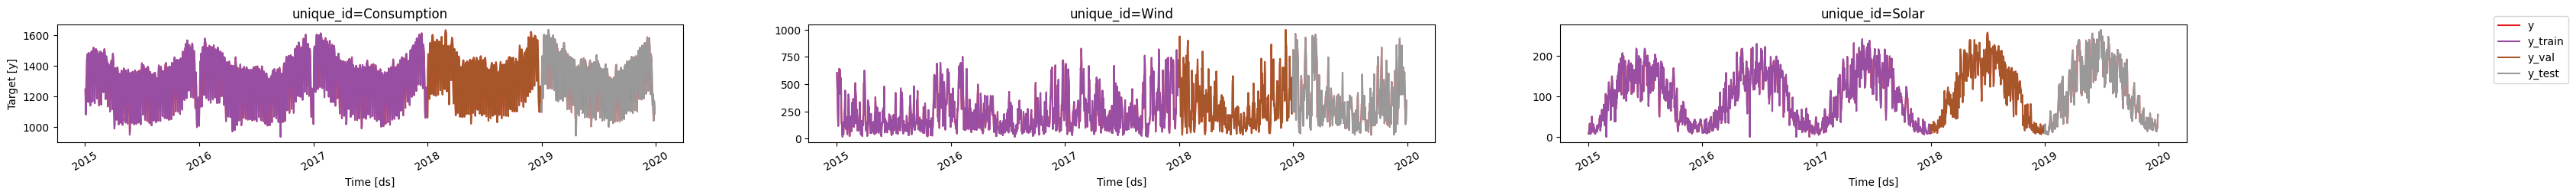

In [21]:
plot_series_v2(forecasts_df= df_,  palette='Set1', n_cols = 3)

#### Метрики

In [22]:
metric_map = {
    'mase': partial(mase, seasonality=SEASON),
    'mae': mae,
    'rmse': rmse,
    'smape': smape,
    # 'CPSR':scaled_crps,
    # 'CI':coverage,
    
    # 'SQL':partial(scaled_quantile_loss, seasonality=SEASON),
}
metrics = list(metric_map.values())
metric_names = list(metric_map.keys())

## Обзор DL моделей

В данном примере будут рассмотрены несоклько архитектур нейронных сетей для предсказания значений временных рядов. 
Рассмотрим следующие архитектуры.


<details> <summary> LSTM </summary>

* Архитектура __[`LSTM`](https://nixtlaverse.nixtla.io/neuralforecast/models.nhits.html)__. Архитектура основывается на рекуррентных ячейках с длинной и короткой функцией "паямяти"([`LSTM`](https://arxiv.org/abs/1402.1128)).
В данном фреймворке используется архитектура типа энкодер-декодер, где энкодер состоит из нескольких `LSTM` слоев тогда как декодер состоит из полносявзных слоев. Предсказания осуществляются итерационно. 
Напомним, что струдктура одной [`LSTM`](https://www.bioinf.jku.at/publications/older/2604.pdf) предсавляет собой набор латентных связей (т.н. [gates](https://d2l.ai/chapter_recurrent-modern/lstm.html)). Среди них есть связи для продолжительных зависимостей - продолжительного контекста и связей для отслеживания краковременных изменений. Связи сохраняют и контролируют поток градиентов в длинных последовательностях. Это позволяет сети более эффективно улавливать долгосрочные зависимости и значительно повышает ее способность к обучению на последовательных данных. `LSTM` имеет три гейта (вход, забывание и выход) и отлично справляется с улавливанием долгосрочных зависимостей.
В какой то степери долговременный контекст соответствует тренду и цикличности, в то время как крактовременный контекст соответствует сезонности. В литературе представлено несколько модификций `LSTM`, структура типичной ячейки может [быть представлена](https://colah.github.io/posts/2015-08-Understanding-LSTMs/) как\
<img src="https://nixtla.github.io/neuralforecast1/imgs_models/lstm.png" width="500px">\
<img src="https://www.deeplearningwizard.com/deep_learning/practical_pytorch/images/rnn2n.png" width="500px">\                 
> Напоним что рекуррентные ячейки ([`RNN`](https://onlinelibrary.wiley.com/doiabs/10.1207/s15516709cog1)) явлются в некоторой степени реализацией нелинейного марковского проецсса. Ячейка может быть выражена в виде `state-space` выражения как
> $$  \begin{cases}
   h_{t} = \mathrm{Activation}(x_{t} W^{\intercal}_{ih} + b_{ih}  +  h_{t-1} W^{\intercal}_{hh} + b_{hh}), 
   \\
  \mathbf{y}_{[t+1]}=\mathrm{Activation}(h_{t}W^{out}_{yh} + b_{yh} ).
 \end{cases} $$
> В фреймворке `Neuralforecast` архитектура рекуррентный энкодер-полносвязный декодер представляется [следующим образом](https://nixtla.github.io/neuralforecast1/models.rnn.html):
> $$  \begin{cases}
   h_{t} = \mathrm{Activation}(x_{t} W^{\intercal}_{ih} + b_{ih}  +  h_{t-1} W^{\intercal}_{hh} + b_{hh}), 
   \\
  \mathbf{y}_{[t+1:t+H]}=\mathrm{MLP}(h_{t}).
 \end{cases} $$
> Также отметим, что в фреймворке `Neuralforecast` реализуются модифицированная `LSTM` ячейка - [`GRU`](https://nixtla.github.io/neuralforecast1/models.gru.html). В данной ячейке используется комбинация долговременного и кратковременного контекста.\
> <img src="https://nixtla.github.io/neuralforecast1/imgs_models/gru.png" width="500px">\
> Также в фреймворке может быть найдена архитектура расширенной `RNN` ячейки с использованием некоторого аналога пулинга - т.н. расширение ([`dialation`](https://arxiv.org/abs/1710.02224)). Данный прием позволяет охватить длинные контексты с наименьшим число параметров. Рост значения `dialation` можно рассматривать как низкочастотную фильтацию.\
> <img src="https://nixtla.github.io/neuralforecast1/imgs_models/dilated_rnn.png" width="500px">\
> Также одной из наболее успешных модификаций рекуррентного подхода можно назвать [`DeepAR`](https://www.sciencedirect.com/science/article/pii/S0169207019301888). Данная модель также может быть найдена в [`Neuralforecast`](https://nixtlaverse.nixtla.io/neuralforecast/models.deepar.html). Идея модели заключается в порождении вероятностного прогнозы на основе оптимизированной глубокой авторегрессионной рекуррентной нейронной сети. То есть каждое следующее значение порождается из предсказанного распределения (аналог вероятностного прогназирования). \
> <img src="https://ars.els-cdn.com/content/image/1-s2.0-S0169207019301888-gr3_lrg.jpg" width="500px">\
> Рекуррентные архитектуры имеют ряд приемуществ, такие как простота (низкая вычислительня сложность) и возможность работы с длинными контекстами.
> Однако [у рекурретных архитектур](https://encord.com/blog/time-series-predictions-with-recurrent-neural-networks/)  есть ограничения, такие как проблема исчезающего или взрывающегося градиента, которая влияет на их способность улавливать долгосрочные зависимости, поскольку РНС могут быть развернуты очень далеко назад в этом Ограничения памяти также могут ограничить их производительность при работе с очень длинными последовательностями. Хотя такие методы, как `LSTM` и `GRU`, смягчают некоторые проблемы, другие продвинутые архитектуры, такие как трансформаторы, могут превосходить RNN в некоторых сложных сценариях временных рядов, что требует тщательного выбора модели.
> * __[Проблема исчезающего градиента](https://encord.com/blog/time-series-predictions-with-recurrent-neural-networks/)__ - это проблема, которая влияет на обучение глубоких нейронных сетей, включая рекуррентные нейронные сети (РНС). Она возникает, когда градиенты, указывающие направление и величину обновлений весов сети в процессе обучения, становятся очень маленькими по мере распространения в обратном направлении по слоям. Это явление препятствует способности РНС к изучению дальних зависимостей и может привести к медленному или неэффективному обучению. \
> __Проблема исчезающего градиента__ особенно проблематична в последовательностях, где информация должна запоминаться или распространяться в течение длительного времени, что влияет на способность сети улавливать важные закономерности. Для борьбы с проблемой исчезающего градиента, препятствующей эффективному обучению нейронных сетей, было разработано несколько стратегий. Такие методы, как правильная инициализация веса, нормализация партии, обрезание градиента, пропуск соединений и планирование скорости обучения, играют ключевую роль в стабилизации градиентного потока и предотвращении его безвременной гибели.

<!-- >Архитектура DeepAR получает распределение прогнозов с помощью выборки по методу Монте-Карло с использованием марковской цепи на панельных данных с использованием перекрестного обучения. При этом условная вероятность задается как: $$ -->

<details> <summary> NBEATS </summary>
    
* Архитектура __[`NBEATS`](https://arxiv.org/abs/1905.10437)__ ([Neural Basis Expansion Analysis](https://nixtlaverse.nixtla.io/neuralforecast/models.nbeats.html)) представляет собой глубокую нейронную архитектуру на основе `MLP` с обратными и прямыми остаточными связями. Архитектура `NBEATS`   [одна из наиболее успешных](https://forecastegy.com/posts/multiple-time-series-forecasting-nbeats-python/) остается одной из наболее успешных не реккуррентных архитектур для предсказания ВР [на среднем горзионте предсказаний](https://www.researchgate.net/publication/351512864_N-BEATS_neural_network_for_mid-term_electricity_load_forecasting). По существу архитектура представляет собой набор блоков, каждый из которых имеет два выхода: предсказание в перед и предсказание назад.\
<img src="https://www.researchgate.net/profile/Boris-Oreshkin/publication/351512864/figure/fig1/AS:1023454975365121@1621022089657/N-BEATS-block-diagram_W640.jpg" width="500px">\
Прямое предсказание очевидно предсказывает будущее значения, тогда как обратное предсказание выступает ограничителем порстранства предсказаний.
Модель предсказывает $h$ значений для входного окна (ретроспектива <tt>Lookback Period</tt>) размером $n\cdot h$, где $n, h$ - гиперпараметры.  Слои `NBEATS` соеденены т.н. принципом <tt>Doubly Residual Stacking Of Blocks</tt>. Где входной велчиной для каждого следующего блока является разность предсказаных значений предыдущего блока и его входных значений. Таким образом создается аналог бустинга. Последний блок называется <tt>Stack Backcast output</tt>. Выходное предсказание формируется как сумма результатов для каждого из блока<tt> Stack Forecast Output</tt>.\
<img src=https://www.researchgate.net/profile/Boris-Oreshkin/publication/351512864/figure/fig1/AS:1023454975365121@1621022089657/N-BEATS-block-diagram_W640.jpg" width="200px"> \
Отметим, что архитектура [`NBEATS`](https://arxiv.org/abs/1905.10437) имеет два варианта:
    * (1) в [интерпретируемой конфигурации](https://www.kaggle.com/code/gatandubuc/forecast-with-n-beats-interpretable-model)
    *  `NBEATS` последовательно проецирует сигнал на полиномы и гармонический базис для изучения компонентов тренда и сезонности;
    * (2) в общей конфигурации она заменяет полиномиальный и гармонический базис на базис идентичности и увеличивает глубину сети.
    * Анализ расширения нейронного базиса с учетом экзогенных факторов ([`NBEATSx`](https://arxiv.org/abs/2104.05522)) включает в себя проекции на экзогенные временные переменные, доступные на момент прогнозирования.\
[Интерпретируемая архитектура](https://nixtlaverse.nixtla.io/neuralforecast/models.nbeats.html) рекомендуется для работы с ограниченными данными, поскольку она упорядочивает  прогнозы с помощью проекций на гармоническую и трендовую базы, что хорошо подходит для большинства задач прогнозирования.\
Для получения [тренда и сезонности](https://arxiv.org/pdf/1905.10437) в интерпретируемой архитектуре авторы предлагают замену последнего слоя на полиномиальную аппроксимацию (тренд) и разложение в ряд Фурье ($sin$ и $cos$ соответственно). [Примеры nen](https://github.com/philipperemy/n-beats/blob/master/nbeats_pytorch/model.py) того как это выглядит показаны ниже.
|<img src="https://miro.medium.com/v2/resize:fit:1286/format:webp/1*Jznia_xjulaUbpNLATh_wg.png" width="300px">|<img src="https://miro.medium.com/v2/resize:fit:1286/format:webp/1*ERhjDwMuDkhktYisCsFoQQ.png" width="300px"> |<img src="https://miro.medium.com/v2/resize:fit:1286/format:webp/1*pqJxiTLGVSf_OZqTrHYT1A.png" width="300px">|
|---|---|---|
|полный блок `N-BEATS`|блок тренда `N-BEATS` |блок периода `N-BEATS`|   

<!-- https://nixtla.github.io/neuralforecast/imgs_models/nbeats.png -->

<details> <summary> NHITS </summary>

* Архитектура __[`NHITS`](https://arxiv.org/abs/2201.12886)__ - Нейронная иерархической интерполяции временных рядов ([Neural Hierarchical Interpolation for Time Series, NHITS](https://nixtlaverse.nixtla.io/neuralforecast/models.nhits.html)) является расширением идеи [`NBEATS`](https://arxiv.org/abs/1905.10437) для предсказаний на длинные горизонты. Указывается, что при прогнозе на длинные горизонты оснвные две проблемы это волатильность и вычислительная сложность. Модель [`NHITS`](https://github.com/cchallu/n-hits) решает эти проблемы путем  много-масштабного семплинга входа и выхода и иерархической интерполяции. Семплинг [реализуется](https://unit8co.github.io/darts/generated_api/darts.models.forecasting.nhits.html) за счет операции `MaxPooling`. Указанные операции позволяют методу [`NHITS`](https://github.com/cchallu/n-hits) собирать свои прогнозы последовательно, выборочно выделяя компоненты с различными частотами и масштабами при декомпозиции входного сигнала и при синтезе прогноза. Ожидается что семплинг будет некоторым аналогом разложения ВР на компоненты. Таким образом в отличии от [`NBEATS`](https://arxiv.org/abs/1905.10437) принцип бустинга заменяется на принцип декомпозиции на некоторый аналог эмпирических мод. Однако, для восстоновления исходной размерности после обработки семплированных мод используется интерполяция. Интерполяция может быть как линейной, так и кубической. <img src="https://github.com/cchallu/n-hits/raw/main/images/nhits-arch.png" width="500px">
> Отметим, что [подобно](https://unit8co.github.io/darts/generated_api/darts.models.forecasting.nhits.html) `NBEATS`, в дополнение к одномерной версии, представленной в статье, эта реализация также поддерживает многомерные ряды (и ковариаты), предсавляя входные данные модели до одномерного ряда и преобразуя выходные данные в тензор соответствующих размеров. Кроме того, модель также поддерживает создание вероятностных прогнозов (путем указания параметра правдоподобия).
> [Особенностью архитектуры](https://www.datasciencewithmarco.com/blog/all-about-n-hits-the-latest-breakthrough-in-time-series-forecasting) является использование передискретизации (макс-пулинга) как метода выделения все более низко-частотных компонент. <img src="https://cdn-images-1.medium.com/max/800/1*_1Q15mryT59_WEWuhghATw.png" width="500px">
>
<img src="https://ai2-s2-public.s3.amazonaws.com/figures/2017-08-08/3667179eca208e4b609089c5dc25387294272007/2-Figure1-1.png" width="500px">
https://www.catalyzex.com/paper/arxiv:2210.02186

<details> <summary> Vanilla Transformer </summary>
    
* Трансформер __([Vanilla Transformer](https://arxiv.org/pdf/2012.07436))__ представляет собой сочитание [нескольких интуиций](https://huggingface.co/blog/time-series-transformers) в отношении [временных рядов](https://nixtlaverse.nixtla.io/neuralforecast/models.vanillatransformer.html). \
 \* Начнем с того, что использование архитектуры кодировщик-декодировщик (`encoder`-`decoder`) интуитивно позволяет генерировать последовательности предсказаний (с заданным горизонтом) в подход `sequence2sequence`. При этом мы можем, задав некоторый тип распределения, породить выборку из него, чтобы получить прогнозы до желаемого горизонта предсказания. Это известно как жадная выборка/поиск предсказаний, \
 \* Во-вторых, архитеткуры типа трансформатор помогает обучаться на продолжительных  временных рядах, которые могут содержать тысячи временных точек и соразмерные горизонты прогнозирования. Ввод в модель всей истории временного ряда за один раз может быть нецелесообразен из-за ограничений по времени и памяти механизма внимания.\
      <tt> Отметим, что таким образом, можно рассмотреть некоторое подходящее контекстное окно и выбрать это окно и последующее окно с размером длины предсказания из обучающих данных при формироании батчей для стохастического градиентного спуска (`SGD`). При этом окно с размером контекста может быть передано кодировщику, а окно предсказания - декодеру с каузальной маской. __Казуальная маска__ означает, что декодер может просматривать только предыдущие временные шаги при обучении следующему значению.</tt>\
 \* Еще одно преимущество архитектур `Transformer` по сравнению с другими архитектурами заключается в том, что мы можем включать отсутствующие значения (пропуски, несинхронность встречаются во временных рядах) в качестве дополнительной маски для кодера или декодера и продолжать обучение, не прибегая к их заполнению или фильтрации. Такая маска будет называться `attention_mask`.  Кроме того, поскольку `Transformer` может перестраиваться или узнавать ложные корреляции гораздо легче, чем другие методы.\
 \* При этом недостатком оригинальной (`Vanilla`) архитектуры `Transformer` является ограничение размеров контекстного окна и окна предсказания из-за квадратичных требований к вычислениям и памяти.\
 <img src="https://www.researchgate.net/publication/373287556/figure/fig1/AS:11431281211958098@1702516201905/The-informer-model-for-time-series-prediction_W640.jpg" width="500px">


<details> <summary> informer </summary>

>* [Отметим](https://arxiv.org/pdf/2012.07436), что в случае многомерных отображений ВР учет полной размерности данных  может оказаться вычислительно сложным, поэтому  прибегают к некоторой аппроксимации распределения, проще всего моделируя каждую компоненту как независимое распределение из того же семейства, или некоторую низкоранговую аппроксимацию и т.д.\
В первую очередь вычислительная сложность обсуловлена операциями внимания. Этот слой требует $O(T^2)$ операций, где $T$ - размер окна ВР. Эта проблема особенно актуальна при длинных горизонтах прогнозирования `Long sequence time-series forecasting` __`(LSTF problem)`__. Одно из решений этой проблемы известно как `ProbSparse` идея этого метода в использовании эффекта __разряженности моделей__. В архитектуре __[`informer`](https://arxiv.org/pdf/2012.07436)__ для снижения чила операций до $O(T \cdot log T)$. \
Vanilla self attention vs `ProbSparse` attention  иллюстрация из работы [Autoformer paper](https://wuhaixu2016.github.io/pdf/NeurIPS2021_Autoformer.pdf)\
<img src="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/blog/informer/informer_full_vs_sparse_attention.png" width="700px">\
Таким образом общая архитектура  [`informer`](https://github.com/zhouhaoyi/Informer2020) будет [иметь вид](https://www.mdpi.com/2073-8994/15/4/951)
<img src="https://www.mdpi.com/symmetry/symmetry-15-00951/article_deploy/html/images/symmetry-15-00951-g001.png" width="500px">\
В дополнение к `ProbSparse` архитектура [`informer`](https://huggingface.co/docs/transformers/en/model_doc/informer) может использоваться дистиляция слоя `attention`. Этим число параметров энкодера урезается в 2 раза. Также в данной архитектуре используется генеративное предсказание выходной последовательности целиком. Это упрощает и ускоряет процесс работы модели.

<details> <summary> autoformer </summary>

>* Также одна из интересных последних архитектур __[`autoformer`](https://arxiv.org/pdf/2106.13008)__ представляет идею того, что помимо боков трансформеров следует проводить разложение моделйе ВР на стандартные компоненты (тренд, сезонность, остаток) при помощи `Decomposition Layer`. Данная модель также предлагает альтернативу архитектуре слоя внимания - `auto-correlation mechanism`.  Этот подход по меньшей мере снижает вычислительную сложность по сравнению с вниманием до нескольких $T \log{T}$ [(если операция реализуется через быстрое преобразование Фурье)](https://huggingface.co/blog/autoformer). По существу модель возвращает архитектурные решения, разработанные для текстов в архитектурах-трансформерах к их более нативному (интерпретируемому) виду для архитектур моделей временных рядов.\
<img src="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/blog/148_autoformer/autoformer_architecture.png" width="500px">\
Ааналогичные решения с декомпозицией были применены в архитектурах [`DLinear`](https://arxiv.org/pdf/2205.13504) и [`FEDformer`](https://arxiv.org/pdf/2201.12740).

<details> <summary> Temporal Fusion Transformer </summary>

* Модель __Temporal Fusion Transformer [`TFT`](https://arxiv.org/abs/1912.09363)__ представляет собой [гибридную архитектуру](https://github.com/google-research/google-research/tree/master/tft), объединяющую `LSTM`-кодирование временных рядов и интерпретируемость слоев внимания трансформатора. Прогнозирование базируется как на основном  ВР (авторегрессионная переменная), так и для ковариатов к ним. В данной архитектуре можно провести разделение ковариатов на статические (постоянные для временного ряда), будущие ковариаты (known, известные заранее для всей истории и будущего) и истонические (наблюдаемые, известные только для исторических данных). Также для архитектуры важно являются ли входные переменные категориальными и непрерывными.\
Переменные встраиваются в высокоразмерное пространство путем обучения вектора встраивания. Встраивания категориальных переменных изучаются в классическом смысле встраивания дискретных значений. Для каждой непрерывной переменной модель обучается одному вектору, который затем масштабируется для дальнейшей обработки. \
Следующим шагом является фильтрация переменных с помощью сети выбора переменных (`Variable Selection Network`, `VSN`). Эта сеть присваивает веса входам в соответствии с их значимостью для предсказания.  Статические переменные используются в качестве контекста для выбора других переменных и в качестве начального состояния `LSTM`-кодировщиков. \
После кодирования переменные передаются в многоголовые слои внимания (декодер), которые формируют окончательное предсказание. Вся архитектура переплетена остаточными связями с механизмами стробирования, которые позволяют архитектуре адаптироваться к различным задачам, пропуская некоторые ее части. \
Блоки архитектуры сопровждаются ячейкми блокировки (Gated residual network, GRN), которые позволяют архитектуре адаптироваться к различным проблемам, пропуская некоторые ее части. \
[Таким образом](https://nixtlaverse.nixtla.io/neuralforecast/models.tft.html) `TFT` сочетает в себе слои стробирования, рекуррентный энкодер `LSTM` и многоголовые слои внимания для декодера с многоступенчатой стратегией прогнозирования. Модель позволяет предсказывать доверительные интервалы для нескольких будущих значений временных рядов. 
<img src="https://github.com/NVIDIA/DeepLearningExamples/raw/master/PyTorch/Forecasting/TFT/TFT_architecture.PNG" width="700px">
<img src="https://developer-blogs.nvidia.com/wp-content/uploads/2022/02/Time-Series-Forecast_Pic-3-768x533.png" width="500px">
>Отметим, что в данной реализации отличие от эталонной в том, что решает проблему недостающих данных, которая часто встречается в производственных наборах данных, либо маскируя их значения в матрицах внимания, либо встраивая их как особое значение в латентное пространство.\
>В целях объяснимости, главы слоев самовнимания имеют общие матрицы значений. Это позволяет интерпретировать самовнимание как ансамбль моделей, предсказывающих различные временные паттерны по одному и тому же набору признаков.\
> Другая характеристика, помогающая понять модель, - активация VSN, которая говорит нам, насколько релевантна данный признак для предсказания.\
>Также отметим, что в общем смысле могут быть и другие модификации архитектур внимания. вот некоторое их [summary](https://seunghan96.github.io/ts/ts56/):
><img src="https://seunghan96.github.io/assets/img/ts/img305.png" width="500px">

<details> <summary> DLinear </summary>
    
* Некоторой модификацией идей внимания, трансформеров и других подходов является ахритектура [`DLinear`](https://arxiv.org/pdf/2205.13504). Авторы ставят вопрос о необходимости использования трансформеров для прямого предсказания для длинном горизонте. Предполагается что эту идеию можно заменить любой нелинейной операцией. Наиболее интерпретируемая из таких операций с точки зрения авторов - это разложение временного ряда на тренд (плюс цикличность) и сезонность и их независимая фильтрация. Идея блока архитектуры может быть проиллюстрирована [следующим образом](https://github.com/vivva/DLinear?tab=readme-ov-file):
<img src="https://github.com/vivva/DLinear/raw/main/pics/DLinear.png" width="800px">
>В качестве мотивайии авторы работы [указывают следующую](https://arxiv.org/pdf/2205.13504). "Основная идея трансформера заключается в многоголовый механизме самовнимания, который обладает способностью извлекать семантические корреляции между элементами в длинной последовательности (например, слов в текстах или двухмерных локациях на изображениях). Однако самовнимание в определенной степени инвариантно к перестановкам и «антипорядку». Хотя использование различных методов позиционного кодирования позволяет сохранить некоторую информацию об упорядочивании, все же неизбежны временные потери информации после применения самовнимания поверх них. Обычно это не является серьезной проблемой для семантически насыщенных приложений, таких как NLP.  Например, семантический смысл предложения в значительной степени сохраняется, даже если мы переставляем некоторые
слова в нем. Однако при анализе данных временных рядов семантика в числовых данных обычно отсутствует и нас в основном интересует моделирование временных изменений среди непрерывного набора точек. То есть порядок значений играет наиболее важную роль. Следовательно, мы
ставится следующий интригующий вопрос: Действительно ли трансформеры эффективны для долгосрочного прогнозирования временных рядов? Более того, хотя существующие решения проблем долгосрочного прогноза (LTSF) на основе трансформера демонстрируют значительное повышение точности прогнозирования по сравнению с традиционными методами, в экспериментах все сравниваемые (не трансформеры) базовые модели используют авторегрессионный или итерационный многошаговый (IMS) прогноз, который, как известно, страдает от значительного эффекта накопления ошибок для задачи LTSF.


 

>Отметим, что в целом могут быть и дополнительные блоки, позволяющие оптимизировать архитектуры. Например использование [нормализации Временных рядов](https://openreview.net/pdf?id=cGDAkQo1C0p).

## Знакомство с объектом `NeuralForecast`

### Выбор и настройка моделей

Загрузим несколько тестовых моделей. В том числе рекурретную архитектуру `encoder-decoder` и архитектуру `NHITS`. Для Архитектур будут указаны общие параметры:
* `h` - горизонт предсказания;
* `max_steps` - число эпох обучения;
* `default_root_dir` - путь для сохранения промежуточных результатов.

Корме того архитектура [`LSTM`](https://nixtlaverse.nixtla.io/neuralforecast/models.lstm.html), имеющая `LSTM` `encoder`, и  `MLP` `decoder`.  которая  задана своими:
* `encoder_hidden_size` - число параметров слоев энкодера (по умолчанию 2 слоя)
* `decoder_hidden_size` - число параметров слоев декодера (по умолчанию 2 слоя)

Архитектура [`NHITS`](https://nixtlaverse.nixtla.io/neuralforecast/models.nhits.html)

In [23]:
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, NHITS, DLinear, Informer
from ray import tune
from neuralforecast.auto import AutoNHITS

Обратите внимание на особенность отображения пути! `log_path`

In [24]:
from pathlib import Path
home_dir = Path('~').expanduser()

In [25]:
horizon = test_size//2
log_path = str(home_dir)

models = [
        LSTM(h=horizon,                    # Forecast horizon 
             input_size = 3*horizon,
             max_steps=50,                # Number of steps to train
             scaler_type='standard',       # Type of scaler to normalize data
             encoder_hidden_size=128,       # Defines the size of the hidden state of the LSTM
             decoder_hidden_size=128,       # Defines the number of hidden units of each layer of the MLP decoder  
             default_root_dir=log_path),       
        NHITS(h=horizon,                   # Forecast horizon
              input_size= horizon,      # Length of input sequence
              max_steps=50,               # Number of steps to train
              n_freq_downsample=[1, 1, 1],  # Downsampling factors for each stack output
              default_root_dir=log_path),
        DLinear(h=horizon,                 # Forecasting horizon
                input_size=2*horizon,           # Input size
                max_steps=50,               # Number of training iterations
                moving_avg_window = 2*(horizon//2) + 1,
                val_check_steps=10,          # Compute validation loss every 100 steps
                default_root_dir=log_path), # Stop training if validation loss does not improve
          ]

Seed set to 1
Seed set to 1
Seed set to 1


### Запустим модель на обучение

#### Fit

In [26]:
nf = NeuralForecast(models=models, freq=FREQ)
nf.fit(df=df_train, val_size = val_size)

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\neuralforecast\common\_base_model.py:591: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_encoder │ LSTM          │  199 K │ train │     0 │
│ 4 │ mlp_decoder  │ MLP           │ 16.6 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 215 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 215 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │ 66.4 K │ train │     0 │
│ 5 │ linear_season │ Linear        │ 66.4 K │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 132 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 132 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_steps=50` reached.


#### Predict

In [27]:
y_hat = nf.predict(df_train_val)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Обратите внимание модели работают в Direct Multioutput  режиме - выход размером с заданный в моделях горизонт

In [28]:
y_hat=fix_forecast_format(y_hat)


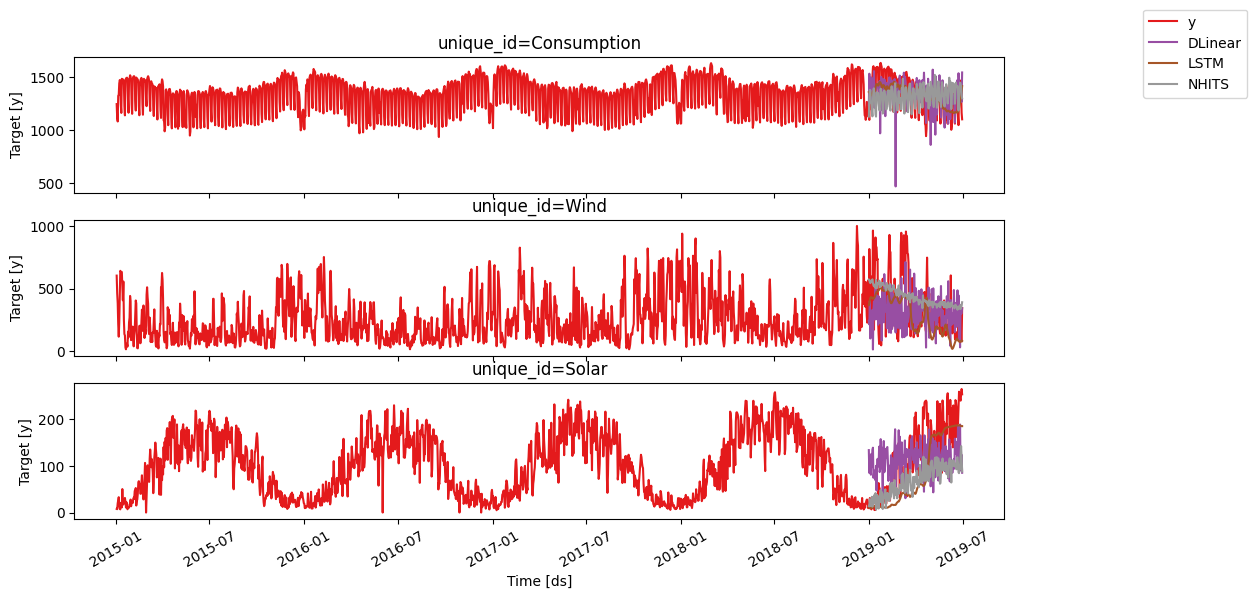

In [29]:
evaluate_and_plot(df_train_val,
                  df_test,
                  forecasts_or_eval = y_hat,
                  metrics = metrics)

#### LongHorzion Forecasting

LongHorzion - это n_step_ahed forecasting, то есть предсказание в несклько шагов. Проще всего его реализовать как кросс валидацию, где шаг равер горизонту (без пересечения) и без повторного обучения

В некоторых версиях нельзя использовать рекуррентные модели с шагом больше 1

In [30]:
nf.models =nf.models[1:]
nf.models

[NHITS, DLinear]

In [31]:
n_steps = (test_size)//horizon

forecasts_df = nf.cross_validation(
        df=panel_df,
        val_size = val_size,
        step_size= horizon,
        test_size= test_size,
        n_windows=None,
        refit = False
    ).drop(columns = ['cutoff'])


C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\neuralforecast\common\_base_model.py:591: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  3.1 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 3.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.1 M                                                                                                
Total estimated model params size (MB): 12                                                                         
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

...

Trainable params: 132 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 132 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_steps=50` reached.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

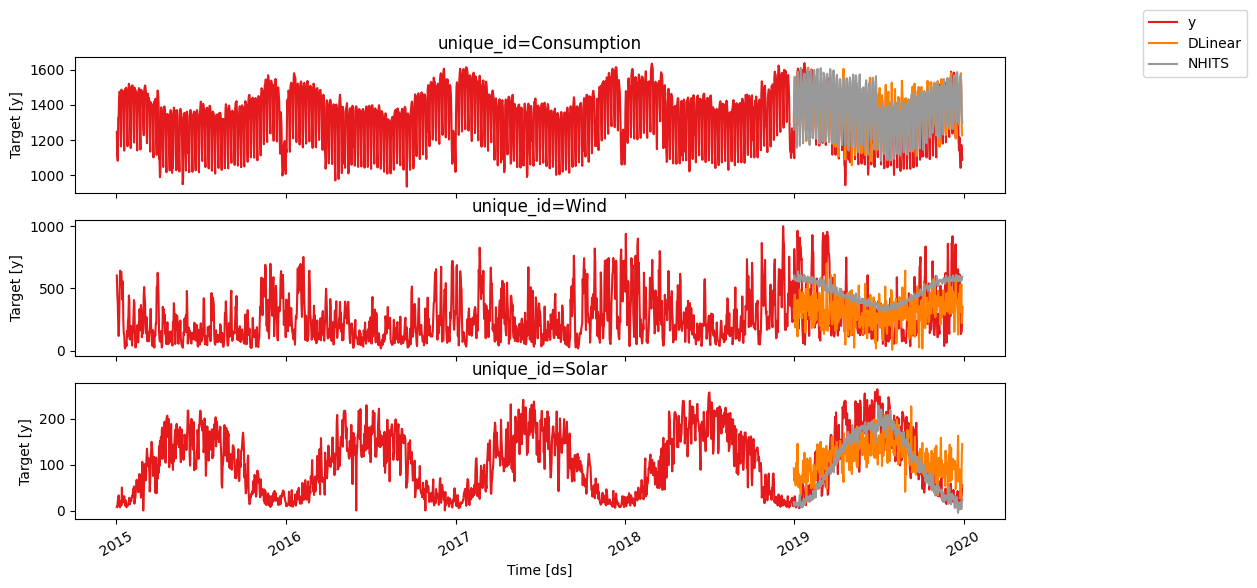

In [32]:
# plot_series_v2(df_train_val,forecasts_df = forecasts_df)
evaluate_and_plot(df_train_val,
                  df_test,
                  forecasts_or_eval = fix_forecast_format(forecasts_df),
                  metrics = metrics)

#### Упражнения
1. Провести несколько экспериментов по настройке гиперпарамертров моделей и сравнить точность

## Продвинутая настройка моделей NeuralForecast

### выбор loss функции

In [33]:
from neuralforecast.losses.pytorch import MSE, RMSE, MAE, SMAPE

loss = SMAPE()  # или RMSE()

In [34]:
models = [
        LSTM(h=horizon,                    # Forecast horizon 
             loss = loss,
             input_size = 3*horizon,
             max_steps=50,                # Number of steps to train
             scaler_type='standard',       # Type of scaler to normalize data
             encoder_hidden_size=128,       # Defines the size of the hidden state of the LSTM
             decoder_hidden_size=128,       # Defines the number of hidden units of each layer of the MLP decoder  
             default_root_dir=log_path),       
        NHITS(h=horizon,                   # Forecast horizon
              loss = loss,
              input_size= horizon,      # Length of input sequence
              max_steps=50,               # Number of steps to train
              n_freq_downsample=[1, 1, 1],  # Downsampling factors for each stack output
              default_root_dir=log_path),
        DLinear(h=horizon,                 # Forecasting horizon
                input_size=2*horizon,           # Input size
                loss = loss,
                max_steps=50,               # Number of training iterations
                moving_avg_window = 2*(horizon//2) + 1,
                val_check_steps=10,          # Compute validation loss every 100 steps
                default_root_dir=log_path), # Stop training if validation loss does not improve
          ]

Seed set to 1
Seed set to 1
Seed set to 1


C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\neuralforecast\common\_base_model.py:591: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ SMAPE         │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_encoder │ LSTM          │  199 K │ train │     0 │
│ 4 │ mlp_decoder  │ MLP           │ 16.6 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 215 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 215 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

...

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

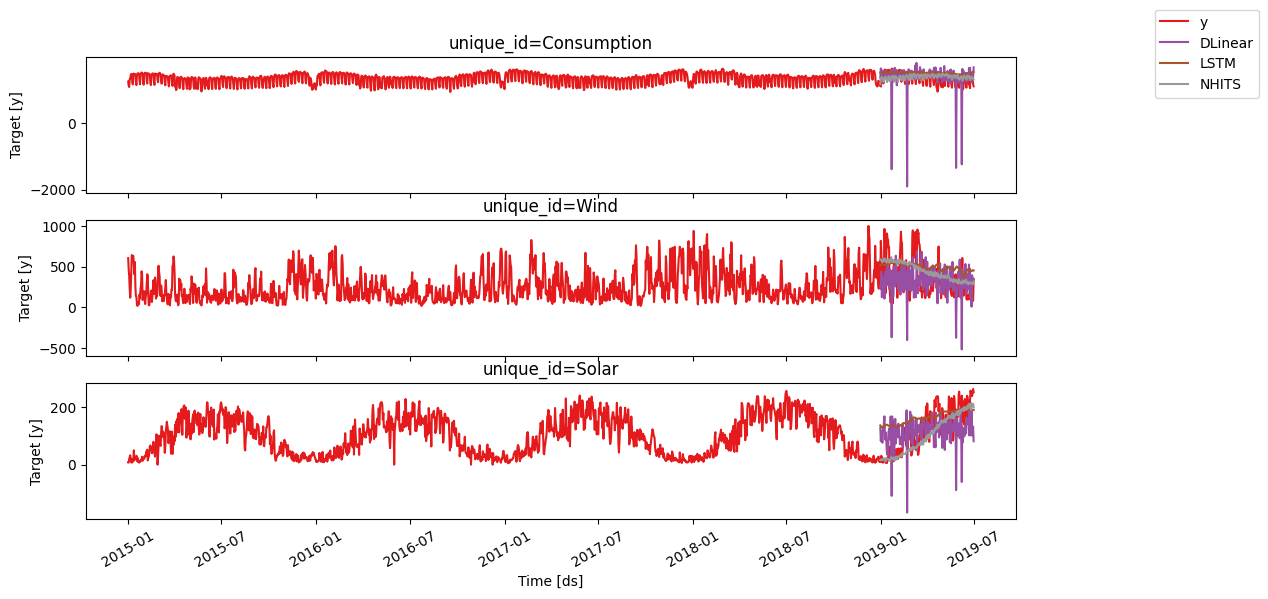

In [35]:
nf = NeuralForecast(models=models, freq=FREQ)
nf.fit(df=df_train, val_size = val_size)
y_hat = nf.predict(df_train_val)
y_hat=fix_forecast_format(y_hat)
evaluate_and_plot(df_train_val,
                  df_test,
                  forecasts_or_eval = y_hat,
                  metrics = metrics)

#### Упражнение
1. Проверить как выбор лосс-функции влияет на резултат прогноза дляразных алгоритмов

### Вероятностное прогнозирование через выбор loss-функции 

Вероятностное прогнозирование является естественным ответом на вопрос о количественной оценке неопределенности будущего целевой переменной. Задача требует моделирования следующего условного прогнозного распределения: 
$$\mathbb{P}(\mathbf{y}_{t+1:t+H} \;|\; \mathbf{y}_{:t})$$
Для этого используем ` multi quantile loss function (MQLoss)`
$$ \mathrm{MQLoss}(y_{\tau}, [\hat{y}^{(q1)}_{\tau},\hat{y}^{(q2)}_{\tau},\dots,\hat{y}^{(Q)}_{\tau}]) = \frac{1}{H} \sum_{q} \mathrm{QL}(y_{\tau}, \hat{y}^{(q)}_{\tau}) $$

In [36]:
from neuralforecast.losses.pytorch import MQLoss

In [37]:
horizon = test_size
levels = [80, 90]
loss=MQLoss(level=levels)

In [38]:
models = [ LSTM(h=horizon,                    # Forecast horizon 
               max_steps=10,                # Number of steps to train
               scaler_type='standard',       # Type of scaler to normalize data
               encoder_hidden_size=128,       # Defines the size of the hidden state of the LSTM
               decoder_hidden_size=128,       # Defines the number of hidden units of each layer of the MLP decoder 
               loss=loss, 
               start_padding_enabled=True, 
               default_root_dir=log_path),      
          NHITS(h=horizon,                   # Forecast horizon
                input_size= horizon,      # Length of input sequence
                max_steps=10,               # Number of steps to train
                loss=loss,
                n_freq_downsample=[1, 1, 1],  # Downsampling factors for each stack output
                start_padding_enabled=True,
                default_root_dir=log_path) ,
           DLinear(h=horizon,                 # Forecasting horizon
                input_size=2*horizon,           # Input size
                max_steps=10,               # Number of training iterations
                moving_avg_window = 2*(horizon//2) + 1,
                val_check_steps=10,          # Compute validation loss every 100 steps
                loss=loss,   
                start_padding_enabled=True,   
                default_root_dir=log_path), # Stop training if validation loss does not improve
          ]

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\neuralforecast\common\_base_model.py:151: UserWarning: Input size too small. Automatically setting input size to 3 * horizon = 1092
  warnings.warn(
Seed set to 1
Seed set to 1
Seed set to 1


C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\neuralforecast\common\_base_model.py:591: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MQLoss        │      5 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_encoder │ LSTM          │  199 K │ train │     0 │
│ 4 │ mlp_decoder  │ MLP           │ 17.2 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 216 K                                                                                            
Non-trainable params: 5                                                                                            
Total params: 216 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

...

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

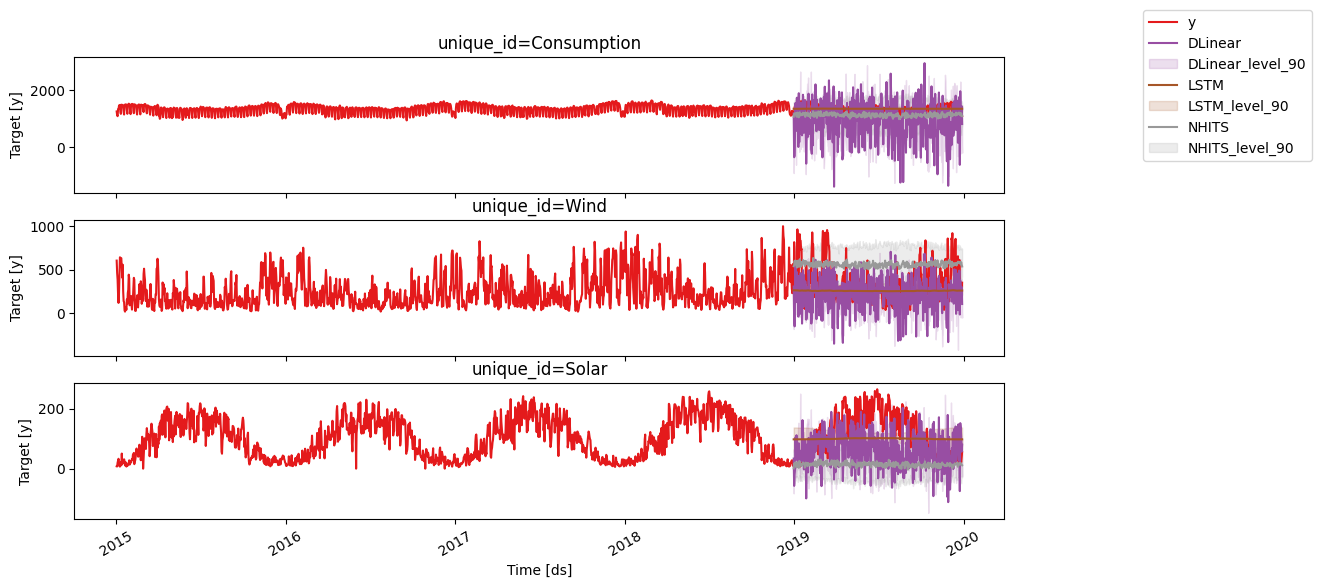

In [39]:
nf = NeuralForecast(models=models, freq=FREQ)
nf.fit(df=df_train, val_size = val_size)
y_hat = nf.predict(df_train_val)
y_hat=fix_forecast_format(y_hat, strip_suffixes=['-median'] )
evaluate_and_plot(df_train_val,
                  df_test,
                  forecasts_or_eval = y_hat,
                  levels=levels[-1:],
                  metrics = metrics)

### Собственная функция потерь

In [40]:
import torch
import torch.nn.functional as F
from neuralforecast.losses.pytorch import BasePointLoss, _weighted_mean

In [41]:
class HuberLoss(BasePointLoss):
    def __init__(self, delta = 0.5,  horizon_weight = None):
        super(HuberLoss, self).__init__(
            horizon_weight=horizon_weight,
            outputsize_multiplier=1,      # Point forecast → 1 output
            output_names=[""]             # Single output name
        )
        self.delta = delta
        self.is_distribution_output = False  # Не распределение, а точка

    def __call__( self,  y, y_hat, y_insample = None, mask = None,):
        losses = F.huber_loss(y, y_hat, reduction="none", delta=self.delta)
        weights = self._compute_weights(y=y, mask=mask)
        return _weighted_mean(losses=losses, weights=weights)

In [42]:
loss = HuberLoss()

In [43]:
models = [ LSTM(h=horizon,                    # Forecast horizon 
               max_steps=10,                # Number of steps to train
               scaler_type='standard',       # Type of scaler to normalize data
               encoder_hidden_size=128,       # Defines the size of the hidden state of the LSTM
               decoder_hidden_size=128,       # Defines the number of hidden units of each layer of the MLP decoder 
               loss=loss, 
               start_padding_enabled=True,   
               default_root_dir=log_path),      
          NHITS(h=horizon,                   # Forecast horizon
                input_size= horizon,      # Length of input sequence
                max_steps=10,               # Number of steps to train
                loss=loss,
                n_freq_downsample=[1, 1, 1],  # Downsampling factors for each stack output
                start_padding_enabled=True,  
                default_root_dir=log_path) ,
           DLinear(h=horizon,                 # Forecasting horizon
                input_size=2*horizon,           # Input size
                max_steps=10,               # Number of training iterations
                moving_avg_window = 2*(horizon//2) + 1,
                val_check_steps=10,          # Compute validation loss every 100 steps
                loss=loss, 
                start_padding_enabled=True,   
                default_root_dir=log_path), # Stop training if validation loss does not improve
          ]

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\neuralforecast\common\_base_model.py:151: UserWarning: Input size too small. Automatically setting input size to 3 * horizon = 1092
  warnings.warn(
Seed set to 1
Seed set to 1
Seed set to 1


C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\neuralforecast\common\_base_model.py:591: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ HuberLoss     │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_encoder │ LSTM          │  199 K │ train │     0 │
│ 4 │ mlp_decoder  │ MLP           │ 16.6 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 215 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 215 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

...

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

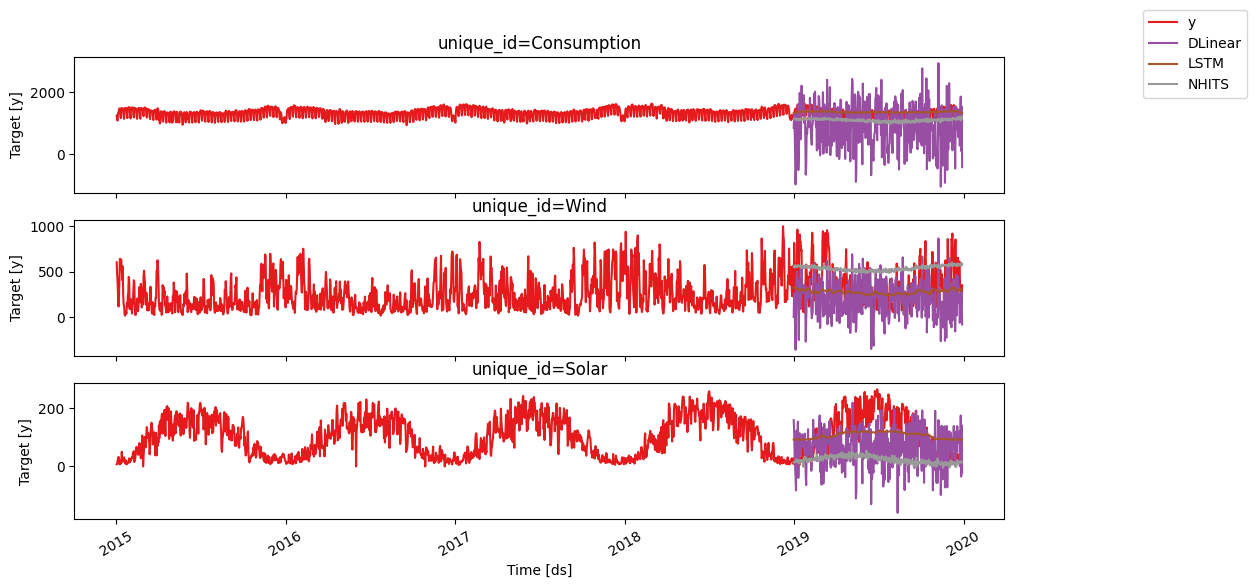

In [44]:
nf = NeuralForecast(models=models, freq=FREQ)
nf.fit(df=df_train, val_size = val_size)
y_hat = nf.predict(df_train_val)
y_hat=fix_forecast_format(y_hat, strip_suffixes=['-median'] )
evaluate_and_plot(df_train_val,
                  df_test,
                  forecasts_or_eval = y_hat,
                  # levels=levels[-1:],
                  metrics = metrics)

#### Упражнение 
1. предлагается сделать квантильный лосс самостоятельно:
   ```python
   torch.max((self.quantile - 1) * error, self.quantile * error)

https://colab.research.google.com/github/Nixtla/neuralforecast/blob/main/nbs/examples/LongHorizon_with_Transformers.ipynb#scrollTo=BDbGGkTax8it

### Модели с автонастройкой

#### Конфигурация модели

In [45]:
from neuralforecast.losses.pytorch import DistributionLoss

In [46]:
from ray import tune
from ray.tune.search.hyperopt import HyperOptSearch

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [47]:
torch.set_float32_matmul_precision('high')

In [48]:
nhits_config = {
       "learning_rate": tune.choice([1e-3]),                                     # Initial Learning rate
       "max_steps": tune.choice([100]),                                         # Number of SGD steps
       "input_size": tune.choice([horizon, 1.5*horizon]),                                 # input_size = multiplier * horizon
       "windows_batch_size": tune.choice([256]),                                 # Number of windows in batch
       "n_pool_kernel_size": tune.choice([[2, 2, 2], [16, 8, 1]]),               # MaxPool's Kernelsize
       "n_freq_downsample": tune.choice([[168, 24, 1], [24, 12, 1], [1, 1, 1]]), # Interpolation expressivity ratios
       "activation": tune.choice(['ReLU']),                                      # Type of non-linear activation
       "n_blocks":  tune.choice([[1, 1, 1]]),                                    # Blocks per each 3 stacks
       "mlp_units":  tune.choice([[[512, 512], [512, 512], [512, 512]]]),        # 2 512-Layers per block for each stack
       "interpolation_mode": tune.choice(['linear']),                            # Type of multi-step interpolation
       "random_seed": tune.randint(1, 10),
       "scaler_type": tune.choice(['robust']),
       "val_check_steps": tune.choice([100]),
       "start_padding_enabled":True,  # ← ключевой параметр
    }

In [49]:
models = [AutoNHITS(h=horizon,
                    loss=DistributionLoss(distribution='StudentT', level=[90]), 
                    config=nhits_config,
                    search_alg=HyperOptSearch(),
                    backend='ray',
                    num_samples=5)]

#### Подбор параметров через кросс-валидацию

In [50]:
nf = NeuralForecast(models=models, freq=FREQ)
# nf.fit(df=df_train, val_size = val_size)
Y_hat_df = nf.cross_validation(df=panel_df, 
                               val_size=val_size,
                               test_size=test_size, 
                               n_windows=None)

(pid=46692) C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
(pid=46692)   import pkg_resources
(_train_tune pid=46692) C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\ray\tune\integration\pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=46692) Seed set to 9
2026-03-11 13:23:54,399	ERROR tune_controller.py:1331 -- Trial task failed for trial _train_tune_960230ac
Traceback (most recent call last):
  File "C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\ray\air\execution\_internal\event_manager.py", line 110, in resolve_future
    result = ray.get(future)
     

(_train_tune pid=47344) ┌───┬──────────────┬──────────────────┬────────┬───────┬───────┐
(_train_tune pid=47344) │   │ Name         │ Type             │ Params │ Mode  │ FLOPs │
(_train_tune pid=47344) ├───┼──────────────┼──────────────────┼────────┼───────┼───────┤
(_train_tune pid=47344) │ 0 │ loss         │ DistributionLoss │      3 │ train │     0 │
(_train_tune pid=47344) │ 1 │ padder_train │ ConstantPad1d    │      0 │ train │     0 │
(_train_tune pid=47344) │ 2 │ scaler       │ TemporalNorm     │      0 │ train │     0 │
(_train_tune pid=47344) │ 3 │ blocks       │ ModuleList       │  4.9 M │ train │     0 │
(_train_tune pid=47344) └───┴──────────────┴──────────────────┴────────┴───────┴───────┘
(_train_tune pid=47344) Trainable params: 4.9 M                                                        
(_train_tune pid=47344) Non-trainable params: 3                                                        
(_train_tune pid=47344) Total params: 4.9 M                                     

2026-03-11 13:24:12,570	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'loss': ('__ref_ph', '0bab4678'), 'mlp_units': ((512, 512), (512, 512), (512, 512)), 'n_blocks': (1, 1, 1), 'n_freq_downsample': (1, 1, 1), 'n_pool_kernel_size': (2, 2, 2), 'valid_loss': ('__ref_ph', 'ab9d4548')}


Epoch 87/-2 ----------------- 0/1 0:00:00 • 0:00:00 0.00it/s v_num: 0.000      
(_train_tune pid=47344)                                                              train_loss_step:  
(_train_tune pid=47344)                                                              5.713             
(_train_tune pid=47344)                                                              train_loss_epoch: 
Epoch 88/-2 ----------------- 0/1 0:00:00 • 0:00:00 0.00it/s v_num: 0.000                     5.713             
(_train_tune pid=47344)                                                              train_loss_step:  
(_train_tune pid=47344)                                                              5.724             
(_train_tune pid=47344)                                                              train_loss_epoch: 
Epoch 88/-2 ----------------- 0/1 0:00:00 • 0:00:00 0.00it/s v_num: 0.000                     5.724             
(_train_tune pid=47344)                                               

(_train_tune pid=47344) `Trainer.fit` stopped: `max_steps=100` reached.
(pid=46632) C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
(pid=46632)   import pkg_resources
(_train_tune pid=46632) C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\ray\tune\integration\pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=46632) Seed set to 4
2026-03-11 13:24:21,102	ERROR tune_controller.py:1331 -- Trial task failed for trial _train_tune_40e97822
Traceback (most recent call last):
  File "C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\ray\air\execution\_internal\event_man

...

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:534: Found 1 module(s) 
in eval mode at the start of training. This may lead to unexpected behavior during training. If this is 
intentional, you can ignore this warning.

`Trainer.fit` stopped: `max_steps=100` reached.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


In [51]:
y_hat = fix_forecast_format(Y_hat_df,strip_suffixes=['-median'])

Внимание! После удаления суффиксов появились дубликаты колонок.


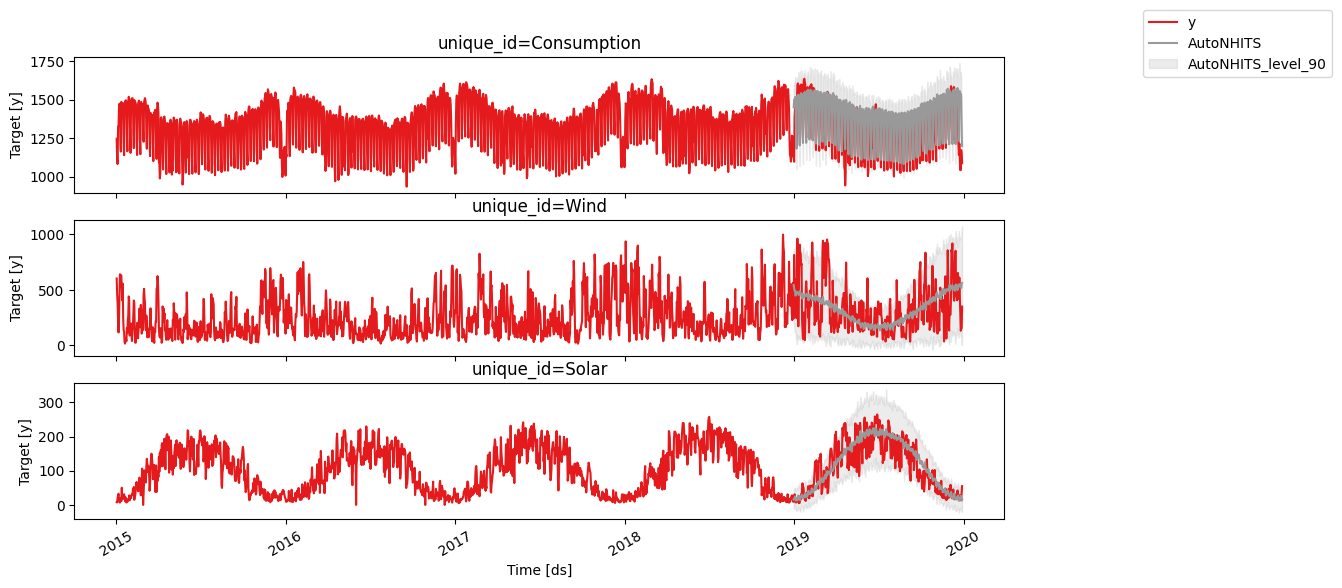

In [54]:
evaluate_and_plot(df_train_val,
                  df_test,
                  forecasts_or_eval = y_hat,
                  levels=levels[-1:],
                  metrics = metrics)

#### Оценка результатов подбора параметров

In [55]:
results = nf.models[0].results.get_dataframe()
results

,loss,train_loss,timestamp,checkpoint_dir_name,done,training_iteration,trial_id,date,time_this_iter_s,time_total_s,...,config/mlp_units,config/interpolation_mode,config/random_seed,config/scaler_type,config/val_check_steps,config/start_padding_enabled,config/h,config/loss,config/valid_loss,logdir
0,5.769274,5.658787,1773217452,None,False,1,e2831a63,2026-03-11_13-24-12,1.937427,1.937427,...,"((512, 512), (512, 512), (512, 512))",linear,5,robust,100,True,364,DistributionLoss(),DistributionLoss(),e2831a63


#### Упражнения
1. Провести настройку параметров для всех указанных алгоритмов и сравнить результаты
   

## [Foundation Models](https://arxiv.org/abs/2504.04011)



### [TimesFM](https://github.com/moment-timeseries-foundation-model/moment/blob/main/tutorials/forecasting.ipynb)

<img src="https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEj4G0lBOLUqlPIXJ3R68kjS984MBIKBPDBrCWtgmjVVTyQRqY6-rn3aHJjgxCbG-8csyBLsp0POILdeJ2VcsRy8lrip0k5DWsUpuL9LU1qOPXLW99mraNdd6HVU791NYqJeTyY7LjuMnOIo6RGmkxBQqqaPrSsC0dELrwy21QUs1Jgwxr8flmdNkDV2tZsT/s16000/image3.jpg" width="700px">

#### Установка

In [56]:
# !pip install timesfm

#### Инициализация

##### Выбор контекстного окна и горизонта предсказния

Как правило контектстное окно 512 значение

Горизонт обычно из набора 96, 192, 364, 760 точек. Но ряд моделей позволяет варьировать горизонт свободно.

In [58]:
CONTEXT_LENGTH = 512
FORECAST_HORIZON = test_size

##### Скачиваем модель с [huggingface](https://huggingface.co/google/timesfm-2.5-200m-pytorch)

In [59]:
import timesfm
import torch

# 1. Инициализация модели
tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend="cpu",       # или "gpu" если есть CUDA
        per_core_batch_size=32,
        horizon_len=FORECAST_HORIZON,      # горизонт прогноза
        context_len=CONTEXT_LENGTH,     # длина контекста (макс 512)
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        huggingface_repo_id="google/timesfm-1.0-200m-pytorch"
    ),
)

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded PyTorch TimesFM, likely because python version is 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)].


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

[Могут быть и другие варианты интерфейса запуска модели](https://github.com/google-research/timesfm?tab=readme-ov-file#code-example)

#### Прогноз

##### подготовка данных

In [61]:
# Воссоздаём series_train и series_test из panel_df
series_train = {
    uid: df_train[df_train["unique_id"] == uid].sort_values("ds")["y"].values.astype(np.float32)
    for uid in ts
}

series_test = {
    uid: df_test[df_test["unique_id"] == uid].sort_values("ds")["y"].values.astype(np.float32)
    for uid in ts
}

# Проверка
for uid in ts:
    print(f"{uid}: train={len(series_train[uid])}, test={len(series_test[uid])}")

Consumption: train=1095, test=364
Wind: train=1095, test=364
Solar: train=1095, test=364


##### прогноз для каждого ряда

In [62]:
forecasts_tfm = {}

for uid in ts:
    train_vals = series_train[uid]
    
    # Берём последние CONTEXT_LENGTH точек
    if len(train_vals) >= CONTEXT_LENGTH:
        context = train_vals[-CONTEXT_LENGTH:]
    else:
        context = train_vals  # TimesFM сам справится с короткими рядами
    
    # TimesFM принимает список массивов
    forecast_input = [context.astype(np.float32)]
    
    # Частота: 0=высокая частота, 1=низкая (для дневных данных используем "D")
    freq_input = [0]  # 0 для high-freq, можно попробовать и 1
    
    point_forecast, experimental_quantile_forecast = tfm.forecast(
        inputs=forecast_input,
        freq=freq_input,
    )
    
    forecasts_tfm[uid] = point_forecast[0]  # shape: (horizon_len,)
    print(f"{uid}: forecast shape = {forecasts_tfm[uid].shape}")

Consumption: forecast shape = (364,)
Wind: forecast shape = (364,)
Solar: forecast shape = (364,)


##### Сборка результатов

In [63]:
results_tfm = []
for uid in ts:
    test_subset = df_test[df_test["unique_id"] == uid].sort_values("ds").reset_index(drop=True)
    actual_len  = len(test_subset)
    predicted   = forecasts_tfm[uid]
    n = min(actual_len, len(predicted))
    
    results_tfm.append(pd.DataFrame({
        "unique_id":  uid,
        "ds":         test_subset["ds"].values[:n],
        "y":          test_subset["y"].values[:n],
        "TimesFM":    predicted[:n]
    }))
    print(f"{uid}: actual={actual_len}, forecast={len(predicted)}, used={n}")

df_results_tfm = pd.concat(results_tfm, ignore_index=True)

Consumption: actual=364, forecast=364, used=364
Wind: actual=364, forecast=364, used=364
Solar: actual=364, forecast=364, used=364


##### evaulate

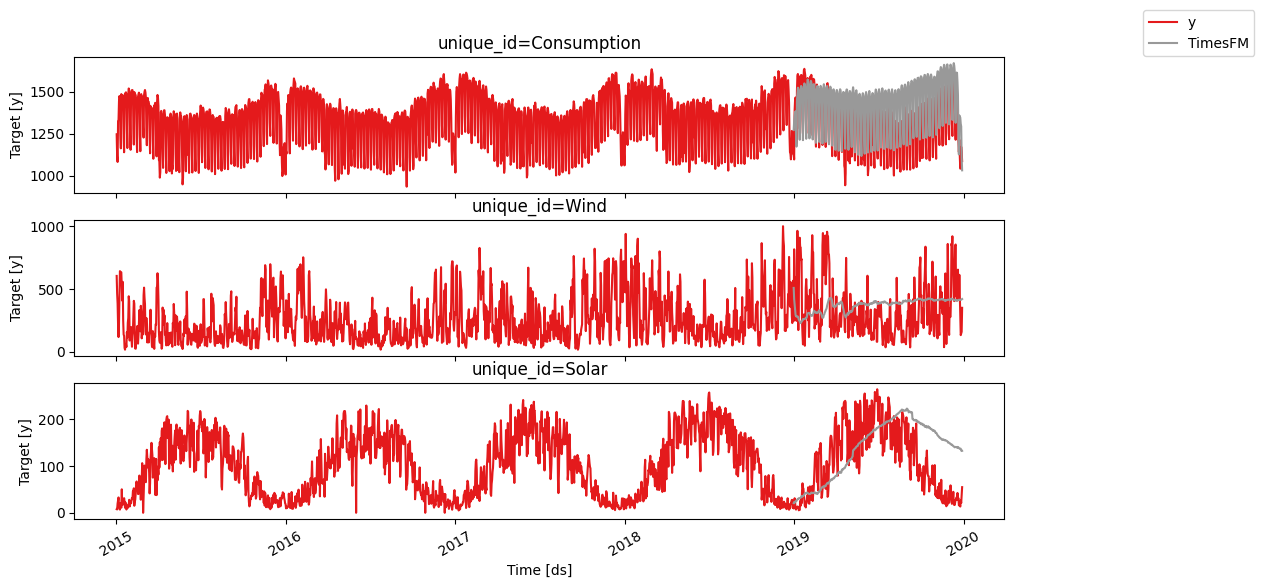

In [64]:
evaluate_and_plot(df_train_val,
                  df_test,
                  forecasts_or_eval = df_results_tfm,
                  # levels=levels[-1:],
                  metrics = metrics)

### [Chronos](https://github.com/amazon-science/chronos-forecasting)

<img src="https://otexts.com/fpppy/img/chronos_archi.png" width="900px">


#### установка

In [65]:
# !pip install chronos-forecasting accelerate

#### Инициализация

#####  горизонт предсказания

In [66]:
FORECAST_HORIZON =  test_size
print(f"Горизонт прогноза: {FORECAST_HORIZON} дней")

Горизонт прогноза: 364 дней


##### Используем Crhonos2 c [HuggingFace](https://huggingface.co/amazon/chronos-2)

In [67]:
# pip install 'pandas[pyarrow]'
from chronos import Chronos2Pipeline
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

#### Конвертация данных

Chronos2Pipeline.predict_df ожидает колонки: id, timestamp, target

#####  Тренировочные данные (контекст)

In [68]:
context_df = df_train[["unique_id", "ds", "y"]].rename(columns={
    "unique_id": "id",
    "ds":        "timestamp",
    "y":         "target"
})

##### Будущие даты (для future_df — без target)

In [69]:
future_df = df_test[["unique_id", "ds"]].rename(columns={
    "unique_id": "id",
    "ds": "timestamp",
})

####  Прогноз

##### predict

In [70]:
LEVEL = [0.1, 0.5, 0.9]

In [71]:
pred_df = pipeline.predict_df(
    context_df,
    future_df=future_df,
    prediction_length=FORECAST_HORIZON,
    quantile_levels=LEVEL,
    id_column="id",
    timestamp_column="timestamp",
    target="target",
    validate_inputs=False,  # отключаем проверку
)

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\torch\utils\data\_utils\pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Memory.cpp:48.)
  return data.pin_memory(device)
C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\torch\utils\data\_utils\pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Memory.cpp:33.)
  return data.pin_memory(device)


##### Сборка результатов

pred_df содержит колонки: id, timestamp, 0.1, 0.5, 0.9

In [72]:
results_chr2 = []
for uid in ts:
    test_subset = df_test[df_test["unique_id"] == uid].sort_values("ds").reset_index(drop=True)
    pred_subset = pred_df[pred_df["id"] == uid].sort_values("timestamp").reset_index(drop=True)
    
    n = min(len(test_subset), len(pred_subset))
    
    results_chr2.append(pd.DataFrame({
        "unique_id":    uid,
        "ds":           test_subset["ds"].values[:n],
        "y":            test_subset["y"].values[:n],
        "Chronos2":     pred_subset["0.5"].values[:n],   # медиана
        "Chronos2-lo-90": pred_subset["0.1"].values[:n],
        "Chronos2-hi-90": pred_subset["0.9"].values[:n],
    }))
    print(f"{uid}: actual={len(test_subset)}, forecast={len(pred_subset)}, used={n}")

df_results_chr2 = pd.concat(results_chr2, ignore_index=True)


Consumption: actual=364, forecast=364, used=364
Wind: actual=364, forecast=364, used=364
Solar: actual=364, forecast=364, used=364


##### evaluate_and_plot

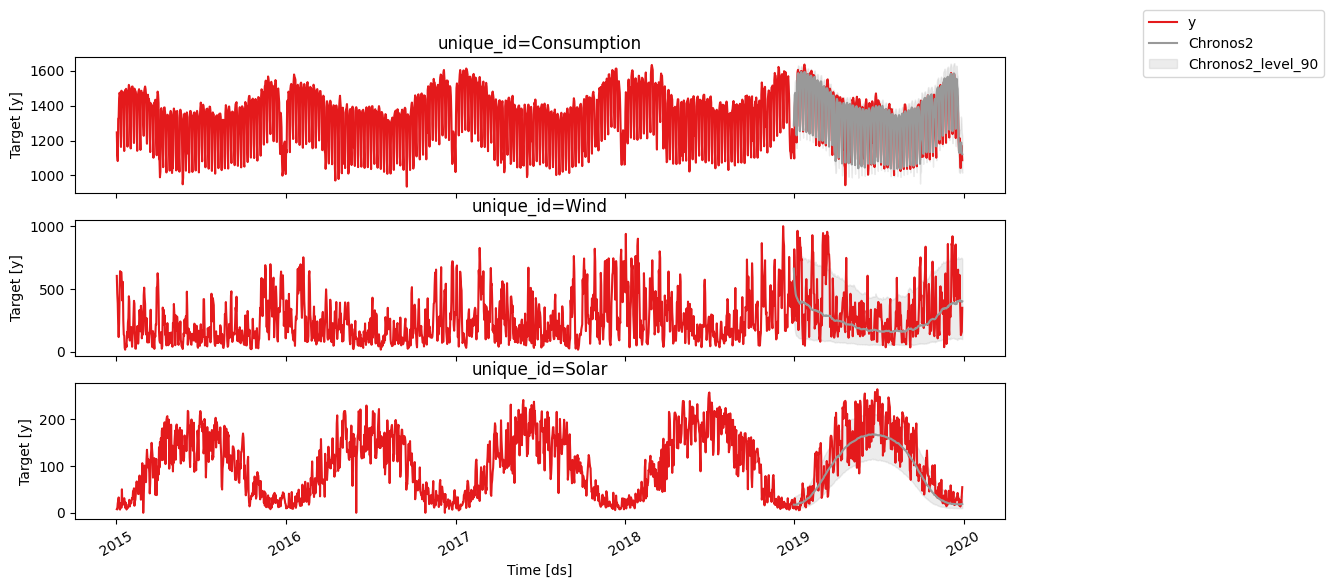

In [73]:
evaluate_and_plot(df_train_val,
                  df_test,
                  forecasts_or_eval = df_results_chr2,
                  levels=[90],
                  metrics = metrics)

### [TinyTimeMixer](https://github.com/ibm-granite/granite-tsfm)

<img src="https://otexts.com/fpppy/img/ttm_archi.png" width="900px">

#### Установка

In [74]:
# !pip install granite-tsfm

#### Инициализация

In [75]:
from tsfm_public import TinyTimeMixerForPrediction
from tsfm_public.toolkit.time_series_forecasting_pipeline import TimeSeriesForecastingPipeline
from tsfm_public.toolkit.dataset import ForecastDFDataset
import torch

##### TTM поддерживает только определенные горизонты: 

Горизонты: 96, 192, 336, 720

Но prediction_filter_length should be positive and less than prediction_length

In [76]:
TTM_HORIZON = 92 

##### [TTM c HF](https://huggingface.co/ibm-granite/granite-timeseries-ttm-r1)

In [77]:
ttm_model = TinyTimeMixerForPrediction.from_pretrained(
    "ibm/TTM",
    revision="main",
    prediction_filter_length=TTM_HORIZON,
)

TTM_CONTEXT = ttm_model.config.context_length  # обычно 512
print(f"TTM context_length = {TTM_CONTEXT}, horizon = {TTM_HORIZON}")

TTM context_length = 512, horizon = 92


#### Predict

##### Прогноз

In [78]:
forecasts_ttm = {}
for uid in ts:
    train_vals = series_train[uid].astype(np.float32)    
    if len(train_vals) >= TTM_CONTEXT:
        context = train_vals[-TTM_CONTEXT:]
    else:
        pad = np.zeros(TTM_CONTEXT - len(train_vals))
        context = np.concatenate([pad, train_vals])    
    # TTM ожидает [batch, context_len, n_channels]
    input_tensor = torch.tensor(context).unsqueeze(0).unsqueeze(-1)  # [1, 512, 1]
    
    with torch.no_grad():
        output = ttm_model(past_values=input_tensor)
    
    # output.prediction_outputs: [batch, horizon, n_channels]
    pred = output.prediction_outputs[0, :, 0].numpy()  # [horizon]
    
    forecasts_ttm[uid] = pred
    print(f"{uid}: forecast shape = {pred.shape}")

Consumption: forecast shape = (92,)
Wind: forecast shape = (92,)
Solar: forecast shape = (92,)


##### Сборка результатов

In [79]:
results_ttm = []
for uid in ts:
    test_subset = df_test[df_test["unique_id"] == uid].sort_values("ds").reset_index(drop=True)
    predicted = forecasts_ttm[uid]
    n = min(len(test_subset), len(predicted))
    
    results_ttm.append(pd.DataFrame({
        "unique_id": uid,
        "ds":        test_subset["ds"].values[:n],
        "y":         test_subset["y"].values[:n],
        "TTM":       predicted[:n],
    }))

df_results_ttm = pd.concat(results_ttm, ignore_index=True)


##### оценка

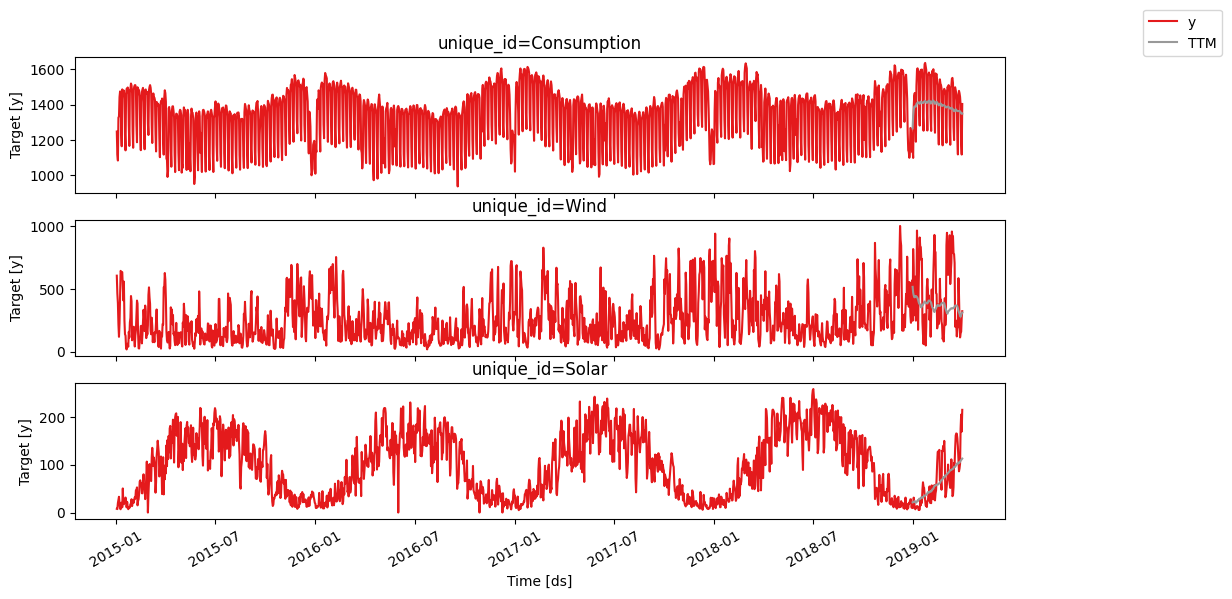

In [80]:
evaluate_and_plot(df_train_val,
                  df_test,
                  forecasts_or_eval = df_results_ttm,
                  # levels=[90],
                  metrics = metrics)

### Упражнения
1. Провести сравнение базисных моделей и ARIMA
2. Провести эксперименты с преобразоваением ВР, например дифференцированием и работй моедей
3. Провести эксперименты с внесением искажений в данные и оценкой результатов для всех моделей
   

## Session Info

In [91]:
import session_info
session_info.show(html=False)

-----
chronos             2.2.2
matplotlib          3.10.8
momentfm            NA
nbformat            5.10.4
neuralforecast      3.1.5
numpy               1.26.4
pandas              2.1.4
pytorch_lightning   2.6.1
ray                 2.54.0
scipy               1.11.4
session_info        v1.0.1
sklearn             1.7.2
statsforecast       2.0.3
timesfm             NA
torch               2.10.0+cu126
torchvision         0.25.0+cu126
tsfm_public         0.3.5
utilits4tsc         NA
utilsforecast       0.2.15
-----
IPython             9.10.0
jupyter_client      8.8.0
jupyter_core        5.9.1
jupyterlab          4.5.5
notebook            7.5.4
-----
Python 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]
Windows-10-10.0.19045-SP0
-----
Session information updated at 2026-03-11 13:33


In [92]:
session_info.show()

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\session_info\main.py:213: DeprecationWarning: Accessing jsonschema.__version__ is deprecated and will be removed in a future release. Use importlib.metadata directly to query for jsonschema's version.
  mod_version = _find_version(mod.__version__)
C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\session_info\main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\session_info\main.py:213: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in Click 9.1. Use feature detection or 'importlib.metadata.version("click")' instead.
  mod_version = _find_version(mod.__version__)


## Дополнительно

### [MomentFM](https://github.com/moment-timeseries-foundation-model/moment)

<img src="https://github.com/moment-timeseries-foundation-model/moment/raw/main/assets/moment_architecture.png" width='500px' >

#### Устанновка

Обратите внимание, может быть даунгрейд Numpy !

[Recommended Python Version: Python 3.11](https://github.com/moment-timeseries-foundation-model/moment?tab=readme-ov-file#%E2%80%8D-usage)

In [81]:
# !pip install momentfm

#### Инициализация модели

##### Скачиваем модель с [huggingface](https://huggingface.co/AutonLab/MOMENT-1-large)

In [82]:
import numpy as np
import torch
from momentfm import MOMENTPipeline

# 1. Инициализация модели
model = MOMENTPipeline.from_pretrained(
    "AutonLab/MOMENT-1-large",
    model_kwargs={
        "task_name": "forecasting",
        "forecast_horizon": horizon # до 96 точек
    },
)
model.init()


C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\momentfm\models\moment.py:174: UserWarning: Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.
  warnings.warn("Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.")


##### Выбор контекста и горизонта предсказания
MOMENT ожидает context_length = 512 (по умолчанию)
MOMENT поддерживает по умолчанию горизонт 96 точек

In [84]:
CONTEXT_LENGTH = 512
FORECAST_HORIZON = 96

#### Прогноз

##### MOMENT требует особый формат данных

In [101]:
# def prepare_moment_data(panel_df, ts_list, split="train"):
#     """
#     Конвертирует панельный df в тензор [n_series, seq_len]
#     """
#     series_dict = {}
#     for uid in ts_list:
#         subset = panel_df[panel_df["unique_id"] == uid].sort_values("ds")
#         series_dict[uid] = subset["y"].values.astype(np.float32)
#     return series_dict


In [86]:
# # 3. Подготовка train/test
# series_train = prepare_moment_data(df_train, ts)
# series_test  = prepare_moment_data(df_test,  ts)

##### Прогноз для каждого ряда

In [106]:
# 4. Нормализация (MOMENT требует нормализованные данные)
def normalize(arr):
    mean = arr.mean()
    std  = arr.std() + 1e-8
    return (arr - mean) / std, mean, std

In [107]:
# Прогноз
forecasts_moment = {}

for uid in ts:
    train_vals = series_train[uid]
    
    if len(train_vals) >= CONTEXT_LENGTH:
        context = train_vals[-CONTEXT_LENGTH:]
        mask = torch.ones(1, CONTEXT_LENGTH)
    else:
        n_pad = CONTEXT_LENGTH - len(train_vals)
        pad = np.zeros(n_pad)
        context = np.concatenate([pad, train_vals])
        mask = torch.ones(1, CONTEXT_LENGTH)
        mask[0, :n_pad] = 0

    ctx_norm, mean, std = normalize(context)
    input_tensor = torch.tensor(ctx_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # [1, 1, 512]

    with torch.no_grad():
        output = model(x_enc=input_tensor, input_mask=mask)

    pred = output.forecast.squeeze().numpy()       # [horizon]
    pred_denorm = pred * std + mean
    forecasts_moment[uid] = pred_denorm
    print(f"{uid}: forecast shape = {forecasts_moment[uid].shape}")

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\torch\utils\checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


Consumption: forecast shape = (364,)
Wind: forecast shape = (364,)
Solar: forecast shape = (364,)


##### Сборка результатов в формат Nixtla для сравнения

In [103]:
results_moment = []
for uid in ts:
    test_subset = df_test[df_test["unique_id"] == uid].sort_values("ds").reset_index(drop=True)
    predicted   = forecasts_moment[uid]
    n = min(len(test_subset), len(predicted))

    results_moment.append(pd.DataFrame({
        "unique_id": uid,
        "ds":        test_subset["ds"].values[:n],
        "y":         test_subset["y"].values[:n],
        "MOMENT":    predicted[:n],
    }))
    print(f"{uid}: actual={len(test_subset)}, forecast={len(predicted)}, used={n}")

df_results_moment = pd.concat(results_moment, ignore_index=True)
print(df_results_moment.head())

Consumption: actual=364, forecast=364, used=364
Wind: actual=364, forecast=364, used=364
Solar: actual=364, forecast=364, used=364
     unique_id         ds         y       MOMENT
0  Consumption 2018-12-31  1148.098  1350.850830
1  Consumption 2019-01-01  1096.818  1337.611450
2  Consumption 2019-01-02  1387.561  1345.311279
3  Consumption 2019-01-03  1450.347  1336.392090
4  Consumption 2019-01-04  1465.718  1334.138794


##### evaluate_and_plot

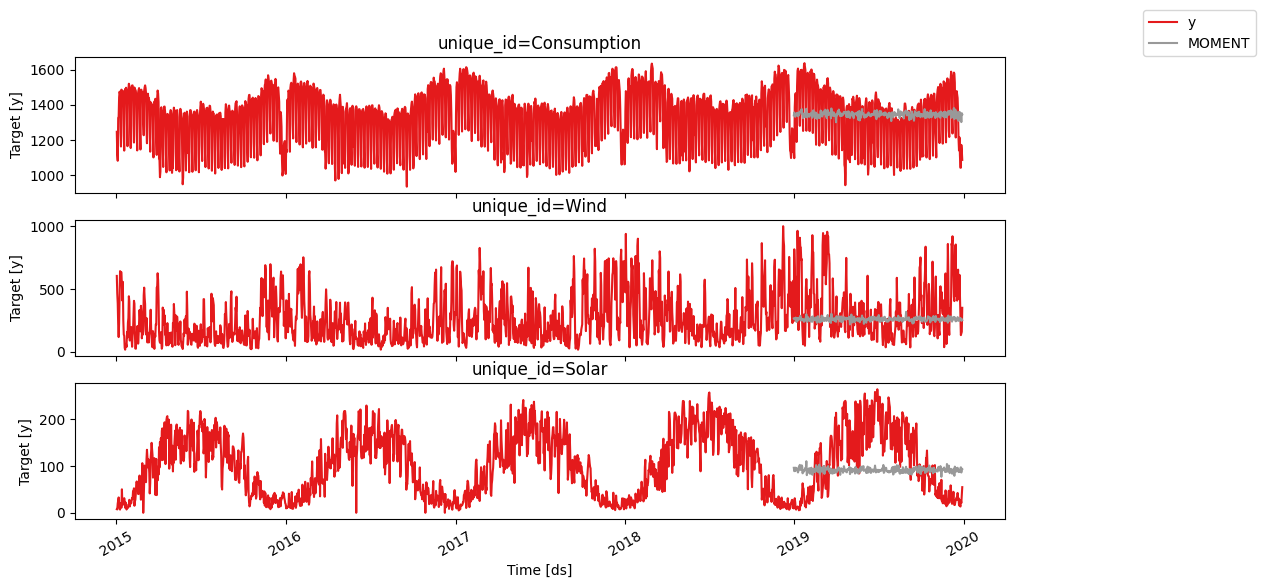

In [105]:
evaluate_and_plot(df_train_val,
                  df_test,
                  forecasts_or_eval = df_results,
                  # levels=levels[-1:],
                  metrics = metrics)

### FineTuning Moment

[Можно найти урок тут](https://github.com/moment-timeseries-foundation-model/moment/blob/main/tutorials/forecasting.ipynb)

In [114]:
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

# 1. Dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, series_dict, context_len=512, horizon=96):
        self.samples = []
        for uid, vals in series_dict.items():
            vals = vals.astype(np.float32)
            # Скользящее окно по каждому ряду
            for i in range(len(vals) - context_len - horizon + 1):
                x = vals[i : i + context_len]
                y = vals[i + context_len : i + context_len + horizon]
                self.samples.append((x, y))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        x, y = self.samples[idx]
        # Нормализация
        mean, std = x.mean(), x.std() + 1e-8
        x_norm = (x - mean) / std
        y_norm = (y - mean) / std  # нормализуем таргет той же статистикой
        return (
            torch.tensor(x_norm).unsqueeze(0),  # [1, context_len]
            torch.tensor(y_norm),                # [horizon]
            torch.tensor(mean),
            torch.tensor(std),
        )

# 2. Инициализация с нуля
CONTEXT_LENGTH = 512
horizon = min(test_size, 96)

model = MOMENTPipeline.from_pretrained(
    "AutonLab/MOMENT-1-large",
    model_kwargs={
        "task_name": "forecasting",
        "forecast_horizon": horizon,
    },
)
model.init()

# Замораживаем backbone, обучаем только forecasting head
for param in model.parameters():
    param.requires_grad = False
for param in model.head.parameters():
    param.requires_grad = True

# 3. DataLoader
dataset    = TimeSeriesDataset(series_train, context_len=CONTEXT_LENGTH, horizon=horizon)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)
print(f"Samples: {len(dataset)}, Batches: {len(dataloader)}")

# 4. Обучение
EPOCHS = 10
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = OneCycleLR(optimizer, max_lr=1e-3, 
                       steps_per_epoch=len(dataloader), epochs=EPOCHS)
criterion = torch.nn.MSELoss()

model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for x, y, mean, std in dataloader:
        mask = torch.ones(x.shape[0], CONTEXT_LENGTH)  # [batch, context_len]
        
        optimizer.zero_grad()
        output = model(x_enc=x, input_mask=mask)
        
        loss = criterion(output.forecast, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    
    avg = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {avg:.6f}")



Samples: 1464, Batches: 183
Epoch 1/10 — Loss: 1.267276
Epoch 2/10 — Loss: 1.584497
Epoch 3/10 — Loss: 2.342281
Epoch 4/10 — Loss: 2.483973
Epoch 5/10 — Loss: 2.277554
Epoch 6/10 — Loss: 2.043999
Epoch 7/10 — Loss: 1.684882
Epoch 8/10 — Loss: 1.507919
Epoch 9/10 — Loss: 1.337665
Epoch 10/10 — Loss: 1.271821


AttributeError: 'MOMENTPipeline' object has no attribute 'model'

In [116]:
# 5. Инференс после fine-tuning
model.eval()
forecasts_moment_ft = {}

for uid in ts:
    train_vals = series_train[uid].astype(np.float32)
    
    if len(train_vals) >= CONTEXT_LENGTH:
        context = train_vals[-CONTEXT_LENGTH:]
    else:
        n_pad = CONTEXT_LENGTH - len(train_vals)
        context = np.concatenate([np.zeros(n_pad), train_vals])
    
    mean, std = context.mean(), context.std() + 1e-8
    ctx_norm = (context - mean) / std
    
    x = torch.tensor(ctx_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # [1,1,512]
    mask = torch.ones(1, CONTEXT_LENGTH)
    
    with torch.no_grad():
        output = model(x_enc=x, input_mask=mask)
    
    pred = output.forecast.squeeze().numpy() * std + mean
    forecasts_moment_ft[uid] = pred
    print(f"{uid}: shape={pred.shape}")

# 6. Результаты
results_moment_ft = []
for uid in ts:
    test_subset = df_test[df_test["unique_id"] == uid].sort_values("ds").reset_index(drop=True)
    predicted   = forecasts_moment_ft[uid]
    n = min(len(test_subset), len(predicted))
    
    results_moment_ft.append(pd.DataFrame({
        "unique_id":  uid,
        "ds":         test_subset["ds"].values[:n],
        "y":          test_subset["y"].values[:n],
        "MOMENT_FT":  predicted[:n],
    }))

df_results_moment_ft = pd.concat(results_moment_ft, ignore_index=True)



Consumption: shape=(96,)
Wind: shape=(96,)
Solar: shape=(96,)


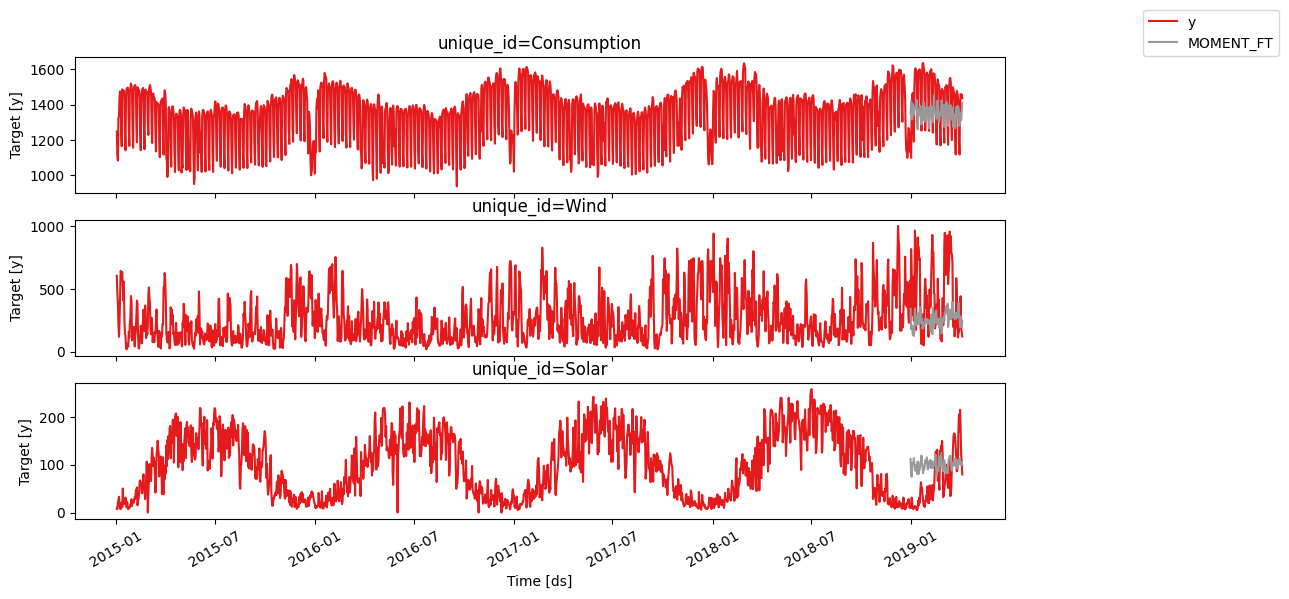

In [117]:
evaluate_and_plot(df_train_val,
                  df_test,
                  forecasts_or_eval = df_results_moment_ft,
                  # levels=levels[-1:],
                  metrics = metrics)

### [Moirai](https://github.com/SalesforceAIResearch/uni2ts)


! __Moirai работает не плохо, но рекомендуется ставить ее в свою виртуальную среду!__



<img src="https://otexts.com/fpppy/img/moirai_archi.png" width="900px">

#### Установка

! Обратите внимание, что установка может тянуть за собой устаревшие зависимости

In [ ]:
# !pip install gluonts
# !pip install "uni2ts" --no-deps
# !pip install einops huggingface_hub safetensors  # только нужные зависимости

#### Инициализация

In [93]:
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule
import torch
from einops import rearrange

##### [Moria HuggingFace](https://huggingface.co/Salesforce/moirai-1.0-R-large)

In [94]:
# 1. Инициализация
SIZE = "large"  # small / base / large
moirai_model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(f"Salesforce/moirai-1.1-R-{SIZE}"),
    prediction_length=FORECAST_HORIZON,
    context_length=CONTEXT_LENGTH,
    patch_size="auto",
    num_samples=100,         # сэмплы для вероятностного прогноза
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=0,
)

##### Проверяем что ожидает модель

In [95]:
print(f"context_length: {moirai_model.hparams.context_length}")
print(f"prediction_length: {moirai_model.hparams.prediction_length}")
print(f"past_length: {moirai_model.past_length}")

MOIRAI_CONTEXT = moirai_model.past_length  # ← используем past_length, не context_length!

context_length: 512
prediction_length: 364
past_length: 876


#### predict

##### Predict c паддингом и интервалами

In [98]:
forecasts_moirai = {}  # ← было [], должно быть {}
for uid in ts:
    train_vals = series_train[uid].astype(np.float32)
    
    if len(train_vals) >= MOIRAI_CONTEXT:
        context = train_vals[-MOIRAI_CONTEXT:]
        is_pad = torch.zeros(1, MOIRAI_CONTEXT, dtype=torch.bool)
    else:
        n_pad = MOIRAI_CONTEXT - len(train_vals)
        pad = np.zeros(n_pad, dtype=np.float32)
        context = np.concatenate([pad, train_vals])
        is_pad = torch.zeros(1, MOIRAI_CONTEXT, dtype=torch.bool)
        is_pad[0, :n_pad] = True

    past_target   = rearrange(torch.tensor(context), "t -> 1 t 1")       # [1, past_length, 1]
    past_observed = (~is_pad).unsqueeze(-1)                               # [1, past_length, 1]

    with torch.no_grad():
        forecast = moirai_model(
            past_target=past_target,
            past_observed_target=past_observed,
            past_is_pad=is_pad,
        )

    # forecast — это уже тензор [batch, num_samples, horizon]
    print(f"{uid}: forecast type={type(forecast)}, shape={forecast.shape}")
    
    samples = forecast[0]  # [num_samples, horizon]

    forecasts_moirai[uid] = {
        "median": samples.median(dim=0).values.numpy(),
        "q10":    samples.quantile(0.1,  dim=0).numpy(),
        "q25":    samples.quantile(0.25, dim=0).numpy(),
        "q75":    samples.quantile(0.75, dim=0).numpy(),
        "q90":    samples.quantile(0.9,  dim=0).numpy(),
    }
    print(f"{uid}: forecast shape = {forecasts_moirai[uid]['median'].shape}")

Consumption: forecast type=<class 'torch.Tensor'>, shape=torch.Size([1, 100, 364])
Consumption: forecast shape = (364,)
Wind: forecast type=<class 'torch.Tensor'>, shape=torch.Size([1, 100, 364])
Wind: forecast shape = (364,)
Solar: forecast type=<class 'torch.Tensor'>, shape=torch.Size([1, 100, 364])
Solar: forecast shape = (364,)


##### Сборка результатов

In [99]:
results_moirai = []
for uid in ts:
    test_subset = df_test[df_test["unique_id"] == uid].sort_values("ds").reset_index(drop=True)
    preds = forecasts_moirai[uid]
    n = min(len(test_subset), len(preds["median"]))
    
    results_moirai.append(pd.DataFrame({
        "unique_id":    uid,
        "ds":           test_subset["ds"].values[:n],
        "y":            test_subset["y"].values[:n],
        "Moirai":       preds["median"][:n],
        "Moirai-lo-90":   preds["q10"][:n],
        # "Moirai_q25":   preds["q25"][:n],
        # "Moirai_q75":   preds["q75"][:n],
        "Moirai-hi-90":   preds["q90"][:n],
    }))

df_results_moirai = pd.concat(results_moirai, ignore_index=True)


##### evaluate_and_plot

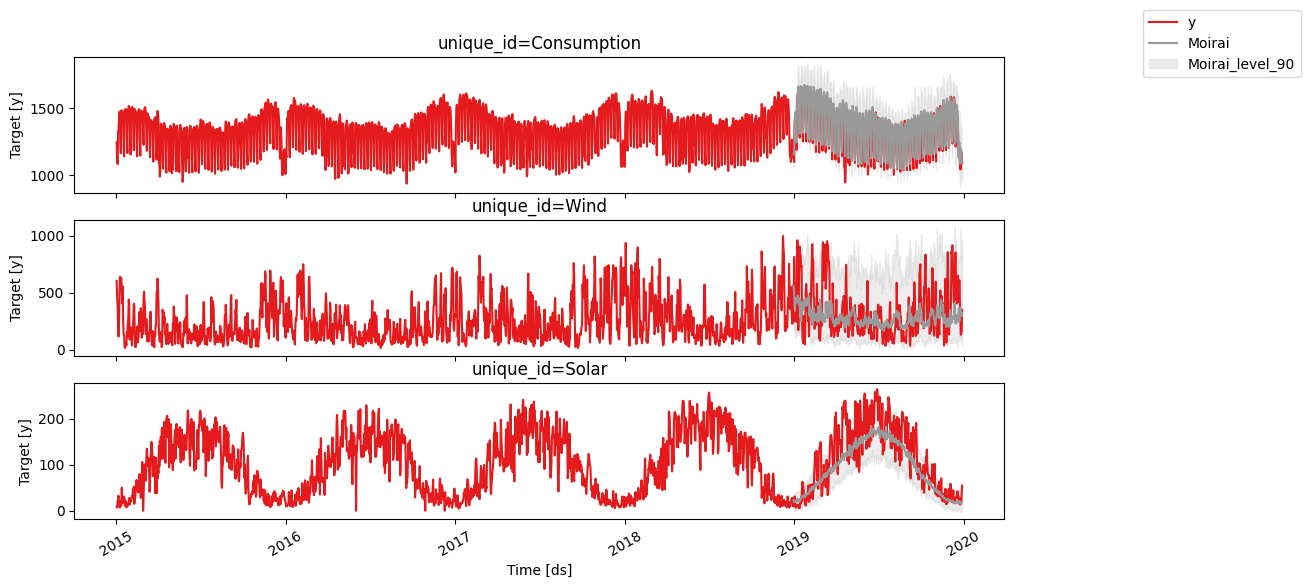

In [100]:
evaluate_and_plot(df_train_val,
                  df_test,
                  forecasts_or_eval = df_results_moirai,
                  levels=[90],
                  metrics = metrics)

### Упражнения
1. Сравнить все модели между собой, составть общий dataframe
2. Попробывать внести искажения в ВР и сравнить модели
 